# BT2: GMM_ACF / GMM_AMDF — cải tiến chọn bằng TRAIN

## 1. Bạn sẽ chạy gì?
Chạy **Runtime → Run all** trên Colab. Notebook tự học ngưỡng từ bốn file train, in bảng train,
kiểm tra giữ riêng từng file train, rồi áp dụng cùng cấu hình lên bốn file test.
Các notebook gốc vẫn được giữ để so sánh. Đây là phiên bản cải tiến sau điều tra ngày 05/10/2026.

**Cấu hình đã chốt lúc 2026-10-05T22:38:17+07:00 bằng train.** Test không tham gia chọn cải tiến.
Kết quả test baseline đã được xem trong phiên trước, nên không gọi test là dữ liệu chưa từng xem.

## 2. Vì sao F0std của bản cũ cao?
F0 là số lần dây thanh rung trong một giây. Một chu kỳ dài T giây thì F0 = 1/T.
ACF có các đỉnh tại T, 2T, 3T; AMDF có các đáy tương ứng. Đỉnh mạnh nhất có thể là 3T.
Ở một khung `phone_F1`, T khoảng 4,6 ms nhưng bản cũ chọn 13,9 ms: F0 xuống khoảng 72 Hz thay vì 217 Hz.
Vài điểm lệch xa làm độ lệch chuẩn tăng mạnh, dù trung bình vẫn gần đúng.
Nhận nhầm im lặng thành hữu thanh cũng làm tăng F0std và F0num.

## 3. Dữ liệu và cách chấm
Hai thư mục cũ có WAV và LAB theo thời gian với nhãn `v`, `uv`, `sil`.
Hai thư mục `*-3groundtruth` có LAB chứa **F0mean, F0std, F0num của cả file**.
Không có F0 chuẩn cho từng khung. Không dùng ba thống kê chuẩn để sửa trực tiếp giá trị dự đoán.

- MAPE từng đại lượng = 100 × |dự đoán − chuẩn| / |chuẩn|.
- Average MAPE của file = trung bình ba MAPE.
- TỔNG CỘNG của mỗi tập = trung bình Average MAPE của bốn file.
- **FINAL SCORE = 100 − TỔNG CỘNG MAPE TEST**; điểm thang 10 = FINAL SCORE / 10, làm tròn một chữ số.

F0std dùng độ lệch chuẩn của toàn bộ F0 hữu hạn (`ddof=0`). F0num đếm toàn bộ F0 hữu hạn,
kể cả dự đoán nhầm ở UV/SIL; không lọc bằng nhãn thật để làm đẹp điểm.


In [1]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path('/content/drive/My Drive/Seventh Semester/Spoken Language Processing/BT2')
# Colab có thể hiển thị cùng Drive dưới tên MyDrive thay vì My Drive.
if not PROJECT_DIR.exists():
    drive_alias = Path(str(PROJECT_DIR).replace('/My Drive/', '/MyDrive/'))
    if drive_alias.exists():
        PROJECT_DIR = drive_alias
TRAIN_DIR = PROJECT_DIR / 'TinHieuHuanLuyen'
TEST_DIR = PROJECT_DIR / 'TinHieuKiemThu'
TRAIN_STATS_DIR = PROJECT_DIR / 'TinHieuHuanLuyen-3groundtruth'
TEST_STATS_DIR = PROJECT_DIR / 'TinHieuKiemThu-3groundtruth'
SHOW_DETAILED_TEST_PLOTS = True
MODEL_CONFIGS = {'GMM_ACF': {'algorithm': 'ACF', 'frame_ms': 20, 'threshold_method': 'gmm', 'candidate': 'path', 'jump_cost': 0.35, 'octave_cost': 0.01, 'median': 3, 'energy': False, 'preprocess': 'raw'}, 'GMM_AMDF': {'algorithm': 'AMDF', 'frame_ms': 25, 'threshold_method': 'gmm', 'candidate': 'near', 'margin': 0.05, 'median': 3, 'energy': True, 'preprocess': 'raw'}}
REFERENCE_TRAIN_VALIDATION = {'GMM_ACF': {'train': {'average_mape': 10.693297260746451, 'F0mean_mape': 1.8298021444129697, 'F0std_mape': 12.01769670255089, 'F0num_mape': 18.23239293527549, 'F0mean_abs_error': 2.6168159443699466, 'F0std_abs_error': 2.9211092693869745, 'macro_f1': 0.7552813153148814, 'balanced_accuracy': 0.851909562650365, 'recall_v': 0.741482168778991, 'recall_uv': 0.9623369565217391, 'TP': 451, 'TN': 175, 'FP': 5, 'FN': 163, 'false_voiced_sil': 12, 'F0num': 468}, 'lofo': {'average_mape': 11.11220903610149, 'F0mean_mape': 1.9199777740443693, 'F0std_mape': 11.320993010267253, 'F0num_mape': 20.095656323992845, 'F0mean_abs_error': 2.6705623061584447, 'F0std_abs_error': 2.7273046729123536, 'macro_f1': 0.7346399523309386, 'balanced_accuracy': 0.8341914559700778, 'recall_v': 0.7160459554184168, 'recall_uv': 0.9523369565217391, 'TP': 423, 'TN': 174, 'FP': 6, 'FN': 191, 'false_voiced_sil': 14, 'F0num': 443}, 'nested_lofo': {'average_mape': 13.260949808836381, 'F0mean_mape': 3.295678936331324, 'F0std_mape': 16.391514166184972, 'F0num_mape': 20.095656323992845, 'F0mean_abs_error': 4.270216933701281, 'F0std_abs_error': 4.057668118671424, 'macro_f1': 0.7346399523309386, 'balanced_accuracy': 0.8341914559700778, 'recall_v': 0.7160459554184168, 'recall_uv': 0.9523369565217391, 'TP': 423, 'TN': 174, 'FP': 6, 'FN': 191, 'false_voiced_sil': 14, 'F0num': 443}}, 'GMM_AMDF': {'train': {'average_mape': 7.811923790621229, 'F0mean_mape': 1.1099789707477106, 'F0std_mape': 7.084287220710573, 'F0num_mape': 15.241505180405401, 'F0mean_abs_error': 1.5334564136450588, 'F0std_abs_error': 1.6163817567635137, 'macro_f1': 0.8150619495893722, 'balanced_accuracy': 0.8998015150595259, 'recall_v': 0.807667546248084, 'recall_uv': 0.9919354838709677, 'TP': 493, 'TN': 178, 'FP': 2, 'FN': 121, 'false_voiced_sil': 0, 'F0num': 495}, 'lofo': {'average_mape': 10.002228237600095, 'F0mean_mape': 1.3236791481095784, 'F0std_mape': 13.179384820445605, 'F0num_mape': 15.503620744245103, 'F0mean_abs_error': 1.9432931556343966, 'F0std_abs_error': 2.866322795445159, 'macro_f1': 0.8119198777125379, 'balanced_accuracy': 0.897752334731657, 'recall_v': 0.8035691855923464, 'recall_uv': 0.9919354838709677, 'TP': 489, 'TN': 178, 'FP': 2, 'FN': 125, 'false_voiced_sil': 1, 'F0num': 492}, 'nested_lofo': {'average_mape': 10.10155664101107, 'F0mean_mape': 1.3837340253535915, 'F0std_mape': 13.417315153434519, 'F0num_mape': 15.503620744245103, 'F0mean_abs_error': 2.016293112292665, 'F0std_abs_error': 2.9118352872862374, 'macro_f1': 0.8119198777125379, 'balanced_accuracy': 0.897752334731657, 'recall_v': 0.8035691855923464, 'recall_uv': 0.9919354838709677, 'TP': 489, 'TN': 178, 'FP': 2, 'FN': 125, 'false_voiced_sil': 1, 'F0num': 492}}}
assert TRAIN_DIR.exists() and TRAIN_STATS_DIR.exists(), 'Thiếu thư mục train hoặc train-3groundtruth'
print('Thư mục dữ liệu:', PROJECT_DIR)


Thư mục dữ liệu: C:\Users\LAPTOP T&T\VIOLETTA\Documents\ChatGPT\XLTN\XLTN-BT2


## 4. Tính đặc trưng từ WAV
Khung dài 20 hoặc 25 ms theo cấu hình của từng thuật toán; bước trượt 10 ms; giữ nguyên tần số lấy mẫu.
Trừ trung bình khung, tính ACF chuẩn hóa hoặc AMDF chuẩn hóa, tìm cực trị trong dải 70–400 Hz,
nội suy parabol để có độ trễ không nguyên. Giữ tối đa 12 ứng viên mạnh nhất mỗi khung.
RMS tương đối = RMS khung / percentile 95 của RMS trong chính file WAV; không dùng nhãn hay 3GT.

Các hàm dưới đây tự chứa toàn bộ thuật toán, không cần tải thêm file Python.


In [2]:
import math

import warnings

from pathlib import Path

import numpy as np

import pandas as pd

from scipy.io import wavfile

from scipy.signal import correlate

from sklearn.mixture import GaussianMixture

EPS = 1e-12

F0_MIN, F0_MAX, HOP_MS = (70.0, 400.0, 10)

HIST_BINS, HIST_SMOOTH_WINDOW, HIST_W = (20, 5, 1.0)

NEAR_ZERO_MEAN_ABS = 1e-08

FIT_CACHE = {}

def build_acf():

    def normalized_acf(frame):
        x = np.asarray(frame, dtype=np.float64)
        x = x - np.mean(x)
        n = len(x)
        if n == 0:
            return np.array([])
        numerator = correlate(x, x, mode='full', method='fft')[n - 1:]
        sq = x * x
        csum = np.concatenate(([0.0], np.cumsum(sq)))
        lags = np.arange(n)
        energy_left = csum[n - lags]
        energy_right = csum[n] - csum[lags]
        denominator = np.sqrt(energy_left * energy_right)
        acf = np.divide(numerator, denominator, out=np.zeros_like(numerator, dtype=np.float64), where=denominator > EPS)
        return acf

    def detect_pitch_acf(frame, fs, f0_min=F0_MIN, f0_max=F0_MAX):
        acf = normalized_acf(frame)
        lag_min = max(1, int(np.ceil(fs / f0_max)))
        lag_max = min(len(frame) - 2, int(np.floor(fs / f0_min)))
        if lag_min > lag_max:
            return (0.0, np.nan, acf)
        candidate_lags = np.arange(lag_min, lag_max + 1)
        local_mask = (acf[candidate_lags] >= acf[candidate_lags - 1]) & (acf[candidate_lags] >= acf[candidate_lags + 1])
        local_lags = candidate_lags[local_mask]
        if len(local_lags) > 0:
            best_lag_int = int(local_lags[np.argmax(acf[local_lags])])
        else:
            best_lag_int = int(lag_min + np.argmax(acf[lag_min:lag_max + 1]))
        periodicity_score = float(acf[best_lag_int])
        best_lag = float(best_lag_int)
        y_m1 = acf[best_lag_int - 1]
        y_0 = acf[best_lag_int]
        y_p1 = acf[best_lag_int + 1]
        denom = y_m1 - 2.0 * y_0 + y_p1
        if abs(denom) > EPS:
            delta = 0.5 * (y_m1 - y_p1) / denom
            if abs(delta) <= 1.0:
                best_lag += float(delta)
        return (periodicity_score, best_lag, acf)

    def lag_to_f0(best_lag, fs):
        if not np.isfinite(best_lag) or best_lag <= 0:
            return np.nan
        return fs / best_lag

    def gaussian_intersection(mu_v, std_v, mu_u, std_u):
        """Tìm nghiệm pV(x)=pU(x), ưu tiên nghiệm nằm giữa hai mean."""
        sv = max(float(std_v), EPS)
        su = max(float(std_u), EPS)
        a = 1.0 / su ** 2 - 1.0 / sv ** 2
        b = -2.0 * mu_u / su ** 2 + 2.0 * mu_v / sv ** 2
        c = mu_u ** 2 / su ** 2 - mu_v ** 2 / sv ** 2 + 2.0 * np.log(su / sv)
        if abs(a) < EPS:
            roots = [] if abs(b) < EPS else [-c / b]
        else:
            roots = np.roots([a, b, c])
        real_roots = [float(np.real(r)) for r in roots if abs(np.imag(r)) < 1e-09]
        lo, hi = sorted([mu_u, mu_v])
        between = [r for r in real_roots if lo <= r <= hi]
        if between:
            return between[0]
        if real_roots:
            midpoint = 0.5 * (mu_u + mu_v)
            return min(real_roots, key=lambda r: abs(r - midpoint))
        return 0.5 * (mu_u + mu_v)

    def histogram_threshold(scores, bins=HIST_BINS, smooth_window=HIST_SMOOTH_WINDOW, W=HIST_W):
        """
        Histogram-based threshold phỏng theo [5]:
          histogram -> smoothing -> local maxima -> T=(W*M1+M2)/(W+1)

        Hai local maxima mạnh nhất được chọn làm hai mode chính.
        Nếu histogram quá phẳng, fallback lấy hai bin có độ cao lớn nhất,
        có ràng buộc không chọn hai bin liền kề.
        """
        scores = np.asarray(scores, dtype=float)
        scores = scores[np.isfinite(scores)]
        if len(scores) < 2:
            raise ValueError('Không đủ score để tính histogram threshold.')
        hist, edges = np.histogram(scores, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        smooth_window = int(max(1, smooth_window))
        if smooth_window % 2 == 0:
            smooth_window += 1
        kernel = np.ones(smooth_window, dtype=float) / smooth_window
        smooth_hist = np.convolve(hist.astype(float), kernel, mode='same')
        local_idx = np.where((smooth_hist[1:-1] >= smooth_hist[:-2]) & (smooth_hist[1:-1] > smooth_hist[2:]))[0] + 1
        ranked = list(local_idx[np.argsort(smooth_hist[local_idx])[::-1]])
        if len(ranked) < 2:
            ranked = list(np.argsort(smooth_hist)[::-1])
        chosen = []
        for idx in ranked:
            if all((abs(int(idx) - int(j)) >= 2 for j in chosen)):
                chosen.append(int(idx))
            if len(chosen) == 2:
                break
        if len(chosen) < 2:
            chosen = [int(np.argmin(centers)), int(np.argmax(centers))]
        m1, m2 = sorted([float(centers[chosen[0]]), float(centers[chosen[1]])])
        threshold = (W * m1 + m2) / (W + 1.0)
        return {'threshold': float(threshold), 'M1': m1, 'M2': m2, 'hist': hist, 'smooth_hist': smooth_hist, 'centers': centers, 'edges': edges, 'peak_indices': np.array(chosen, dtype=int)}

    def class_histogram_threshold(v_scores, u_scores, bins=80, smooth_width=7):
        """Hai histogram density theo nhãn, smoothing rồi tìm giao điểm giữa mean V/UV."""
        all_scores = np.concatenate([v_scores, u_scores])
        x_min, x_max = (float(all_scores.min()), float(all_scores.max()))
        hist_v, edges = np.histogram(v_scores, bins=bins, range=(x_min, x_max), density=True)
        hist_u, _ = np.histogram(u_scores, bins=bins, range=(x_min, x_max), density=True)
        kernel = np.ones(smooth_width, dtype=float) / smooth_width
        smooth_v = np.convolve(hist_v, kernel, mode='same')
        smooth_u = np.convolve(hist_u, kernel, mode='same')
        centers = 0.5 * (edges[:-1] + edges[1:])
        lo, hi = sorted((float(v_scores.mean()), float(u_scores.mean())))
        candidate_idx = np.where((centers >= lo) & (centers <= hi))[0]
        if len(candidate_idx) == 0:
            return (0.5 * (lo + hi), centers, smooth_v, smooth_u)
        diff = smooth_v - smooth_u
        crossings = []
        for idx in candidate_idx[:-1]:
            if diff[idx] == 0 or diff[idx] * diff[idx + 1] < 0:
                best = idx if abs(diff[idx]) <= abs(diff[idx + 1]) else idx + 1
                crossings.append(best)
        if crossings:
            midpoint = 0.5 * (lo + hi)
            best_idx = min(crossings, key=lambda i: abs(centers[i] - midpoint))
        else:
            best_idx = candidate_idx[np.argmin(np.abs(diff[candidate_idx]))]
        return (float(centers[best_idx]), centers, smooth_v, smooth_u)
    return {'normalized_acf': normalized_acf, 'detect_pitch_acf': detect_pitch_acf, 'lag_to_f0': lag_to_f0, 'gaussian_intersection': gaussian_intersection, 'histogram_threshold': histogram_threshold, 'class_histogram_threshold': class_histogram_threshold}

ACF = build_acf()

def build_amdf():

    def lag_search_range(fs, frame_len, f0_min=F0_MIN, f0_max=F0_MAX):
        """Tính miền lag hợp lệ từ dải F0."""
        lag_min = max(1, int(np.floor(fs / f0_max)))
        lag_max = min(frame_len - 1, int(np.ceil(fs / f0_min)))
        if lag_min > lag_max:
            raise ValueError('Frame quá ngắn so với miền lag cần tìm.')
        return (lag_min, lag_max)

    def normalized_amdf(frame, fs, f0_min=F0_MIN, f0_max=F0_MAX):
        """
        Tính normalized AMDF trong miền lag hợp lệ.

        Vector hóa bằng NumPy theo cả trục lag và sample; chỉ tạo ma trận nhỏ
        tương ứng các lag 70–400 Hz, không tính các lag không cần thiết.
        """
        x = np.asarray(frame, dtype=np.float64)
        x = x - np.mean(x)
        lag_min, lag_max = lag_search_range(fs, len(x), f0_min, f0_max)
        lags = np.arange(lag_min, lag_max + 1, dtype=int)
        if np.mean(np.abs(x)) < NEAR_ZERO_MEAN_ABS:
            return (lags, np.ones_like(lags, dtype=np.float64))
        max_overlap = len(x) - lag_min
        n = np.arange(max_overlap)[None, :]
        lag_matrix = lags[:, None]
        valid = n < len(x) - lag_matrix
        idx2 = np.minimum(n + lag_matrix, len(x) - 1)
        x1 = np.broadcast_to(x[:max_overlap][None, :], idx2.shape)
        x2 = x[idx2]
        count = valid.sum(axis=1)
        diff_mean = (np.abs(x1 - x2) * valid).sum(axis=1) / count
        x1_mean_abs = (np.abs(x1) * valid).sum(axis=1) / count
        x2_mean_abs = (np.abs(x2) * valid).sum(axis=1) / count
        namdf = diff_mean / (x1_mean_abs + x2_mean_abs + EPS)
        return (lags, namdf)

    def deepest_local_dip(frame, fs, f0_min=F0_MIN, f0_max=F0_MAX):
        """
        Tìm lowest local dip của normalized AMDF.

        Returns
        -------
        dip_value : float
            Giá trị đáy AMDF dùng làm periodicity score.
        lag : int
            Lag nguyên tại đáy.
        refined_lag : float
            Lag tinh chỉnh bằng nội suy parabol để ước lượng F0 mượt hơn.
        lags, namdf : ndarray
            Dùng cho vẽ minh họa.
        """
        lags, namdf = normalized_amdf(frame, fs, f0_min, f0_max)
        if len(namdf) >= 3:
            local_mask = (namdf[1:-1] <= namdf[:-2]) & (namdf[1:-1] <= namdf[2:])
            local_idx = np.where(local_mask)[0] + 1
        else:
            local_idx = np.array([], dtype=int)
        if len(local_idx) == 0:
            best_idx = int(np.argmin(namdf))
        else:
            best_idx = int(local_idx[np.argmin(namdf[local_idx])])
        dip_value = float(namdf[best_idx])
        lag = int(lags[best_idx])
        refined_lag = float(lag)
        if 0 < best_idx < len(namdf) - 1:
            y1, y2, y3 = namdf[best_idx - 1:best_idx + 2]
            denominator = y1 - 2.0 * y2 + y3
            if abs(denominator) > EPS:
                delta = 0.5 * (y1 - y3) / denominator
                if abs(delta) <= 1.0:
                    refined_lag += float(delta)
        return (dip_value, lag, refined_lag, lags, namdf)

    def f0_from_lag(fs, lag):
        return fs / lag if lag > 0 else np.nan

    def gaussian_threshold(v_scores, u_scores):
        """Chọn giao điểm Gaussian nằm giữa meanV và meanU, giống quy tắc của ACF."""
        mu_v, sv = (float(v_scores.mean()), max(float(v_scores.std()), EPS))
        mu_u, su = (float(u_scores.mean()), max(float(u_scores.std()), EPS))
        a = 1.0 / su ** 2 - 1.0 / sv ** 2
        b = -2.0 * mu_u / su ** 2 + 2.0 * mu_v / sv ** 2
        c = mu_u ** 2 / su ** 2 - mu_v ** 2 / sv ** 2 + 2.0 * np.log(su / sv)
        if abs(a) < EPS:
            roots = [] if abs(b) < EPS else [-c / b]
        else:
            roots = np.roots([a, b, c])
        real_roots = [float(np.real(root)) for root in roots if abs(np.imag(root)) < 1e-09]
        lo, hi = sorted((mu_v, mu_u))
        between = [root for root in real_roots if lo <= root <= hi]
        midpoint = 0.5 * (mu_v + mu_u)
        if between:
            return min(between, key=lambda root: abs(root - midpoint))
        if real_roots:
            return min(real_roots, key=lambda root: abs(root - midpoint))
        return midpoint

    def histogram_threshold(v_scores, u_scores, bins=80, smooth_width=7):
        """
        Histogram smoothing cho hai lớp V/UV rồi tìm điểm giao density.
        Trả thêm dữ liệu histogram để vẽ.
        """
        all_scores = np.concatenate([v_scores, u_scores])
        x_min, x_max = (float(all_scores.min()), float(all_scores.max()))
        hist_v, edges = np.histogram(v_scores, bins=bins, range=(x_min, x_max), density=True)
        hist_u, _ = np.histogram(u_scores, bins=bins, range=(x_min, x_max), density=True)
        kernel = np.ones(smooth_width, dtype=float) / smooth_width
        smooth_v = np.convolve(hist_v, kernel, mode='same')
        smooth_u = np.convolve(hist_u, kernel, mode='same')
        centers = 0.5 * (edges[:-1] + edges[1:])
        lo, hi = sorted((float(v_scores.mean()), float(u_scores.mean())))
        candidate_idx = np.where((centers >= lo) & (centers <= hi))[0]
        if len(candidate_idx) == 0:
            threshold = 0.5 * (lo + hi)
            return (threshold, centers, smooth_v, smooth_u)
        diff = smooth_v - smooth_u
        crossings = []
        for idx in candidate_idx[:-1]:
            if diff[idx] == 0 or diff[idx] * diff[idx + 1] < 0:
                best = idx if abs(diff[idx]) <= abs(diff[idx + 1]) else idx + 1
                crossings.append(best)
        if crossings:
            midpoint = 0.5 * (lo + hi)
            best_idx = min(crossings, key=lambda i: abs(centers[i] - midpoint))
        else:
            best_idx = candidate_idx[np.argmin(np.abs(diff[candidate_idx]))]
        threshold = float(centers[best_idx])
        return (threshold, centers, smooth_v, smooth_u)

    def two_mode_histogram_threshold(scores, bins=HIST_BINS, smooth_window=HIST_SMOOTH_WINDOW, W=HIST_W):
        """Histogram gộp -> smoothing -> hai local maxima -> T=(W*M1+M2)/(W+1)."""
        scores = np.asarray(scores, dtype=float)
        scores = scores[np.isfinite(scores)]
        if len(scores) < 2:
            raise ValueError('Không đủ score để tính histogram hai mode.')
        hist, edges = np.histogram(scores, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        smooth_window = int(max(1, smooth_window))
        if smooth_window % 2 == 0:
            smooth_window += 1
        kernel = np.ones(smooth_window, dtype=float) / smooth_window
        smooth_hist = np.convolve(hist.astype(float), kernel, mode='same')
        local_idx = np.where((smooth_hist[1:-1] >= smooth_hist[:-2]) & (smooth_hist[1:-1] > smooth_hist[2:]))[0] + 1
        ranked = list(local_idx[np.argsort(smooth_hist[local_idx])[::-1]])
        if len(ranked) < 2:
            ranked = list(np.argsort(smooth_hist)[::-1])
        chosen = []
        for idx in ranked:
            if all((abs(int(idx) - int(j)) >= 2 for j in chosen)):
                chosen.append(int(idx))
            if len(chosen) == 2:
                break
        if len(chosen) < 2:
            chosen = [int(np.argmin(centers)), int(np.argmax(centers))]
        m1, m2 = sorted([float(centers[chosen[0]]), float(centers[chosen[1]])])
        return {'threshold': float((W * m1 + m2) / (W + 1.0)), 'M1': m1, 'M2': m2, 'hist': hist, 'smooth_hist': smooth_hist, 'centers': centers, 'edges': edges, 'peak_indices': np.array(chosen, dtype=int)}
    return {'lag_search_range': lag_search_range, 'normalized_amdf': normalized_amdf, 'deepest_local_dip': deepest_local_dip, 'f0_from_lag': f0_from_lag, 'gaussian_threshold': gaussian_threshold, 'histogram_threshold': histogram_threshold, 'two_mode_histogram_threshold': two_mode_histogram_threshold}

In [3]:
AMDF = build_amdf()

def build_gmm():

    def normal_pdf(x, mean, std):
        std = max(float(std), EPS)
        return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2.0 * np.pi))

    def fit_gmm_threshold(scores):
        scores = np.asarray(scores, dtype=float)
        scores = scores[np.isfinite(scores)]
        if len(scores) < 4 or np.std(scores) < 1e-10:
            raise ValueError('Score training quá ít hoặc không biến thiên để fit GMM hai thành phần.')
        model = GaussianMixture(n_components=2, covariance_type='spherical', reg_covar=1e-06, n_init=10, random_state=42).fit(scores.reshape(-1, 1))
        order = np.argsort(model.means_.ravel())
        means = model.means_.ravel()[order]
        stds = np.sqrt(model.covariances_[order])
        weights = model.weights_[order]
        grid = np.linspace(means[0], means[1], 10001)
        low_density = weights[0] * normal_pdf(grid, means[0], stds[0])
        high_density = weights[1] * normal_pdf(grid, means[1], stds[1])
        difference = low_density - high_density
        crossing_indices = np.where(difference[:-1] * difference[1:] <= 0)[0]
        if len(crossing_indices):
            midpoint = 0.5 * (means[0] + means[1])
            index = min(crossing_indices, key=lambda i: abs(grid[i] - midpoint))
            left, right = (difference[index], difference[index + 1])
            fraction = -left / (right - left) if right != left else 0.0
            threshold = float(grid[index] + fraction * (grid[index + 1] - grid[index]))
        else:
            threshold = float(grid[np.argmin(np.abs(difference))])
        return {'model': model, 'means': means, 'stds': stds, 'weights': weights, 'threshold': threshold}
    return {'normal_pdf': normal_pdf, 'fit_gmm_threshold': fit_gmm_threshold}

GMM = build_gmm()

def init_functions():
    return

def read_stats(path):
    stats = {}
    for line in Path(path).read_text(encoding='utf-8').splitlines():
        words = line.split()
        if words and words[0] in {'F0mean', 'F0std', 'F0num'}:
            stats[words[0]] = float(words[1])
    assert set(stats) == {'F0mean', 'F0std', 'F0num'}
    assert all((value > 0 for value in stats.values()))
    return stats

def read_segments(path):
    segments = []
    for line in Path(path).read_text(encoding='utf-8').splitlines():
        words = line.split()
        if words and words[0] not in {'F0mean', 'F0std', 'F0num'}:
            segments.append((float(words[0]), float(words[1]), words[2].lower()))
    assert segments and all((a < b and label in ('v', 'uv', 'sil') for a, b, label in segments))
    return segments

In [4]:
def load_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fs, values = wavfile.read(path)
    if values.ndim > 1:
        values = values.mean(axis=1)
    if np.issubdtype(values.dtype, np.integer):
        info = np.iinfo(values.dtype)
        values = values.astype(float) / max(abs(info.min), info.max)
    else:
        values = values.astype(float)
    return (int(fs), values)

def refine_lag(curve, index, lag):
    if 0 < index < len(curve) - 1:
        a, b, c = curve[index - 1:index + 2]
        denom = a - 2 * b + c
        if abs(denom) > EPS:
            delta = 0.5 * (a - c) / denom
            if abs(delta) <= 1:
                lag += float(delta)
    return lag

def classification(labels, predicted):
    mask = np.isin(labels, ('v', 'uv'))
    truth, pred = (labels[mask] == 'v', predicted[mask])
    tp, tn = (int((truth & pred).sum()), int((~truth & ~pred).sum()))
    fp, fn = (int((~truth & pred).sum()), int((truth & ~pred).sum()))
    rv, ru = (tp / max(tp + fn, 1), tn / max(tn + fp, 1))
    fv, fu = (2 * tp / max(2 * tp + fp + fn, 1), 2 * tn / max(2 * tn + fp + fn, 1))
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 'recall_v': rv, 'recall_uv': ru, 'balanced_accuracy': (rv + ru) / 2, 'macro_f1': (fv + fu) / 2, 'accuracy_vu': (tp + tn) / max(len(truth), 1), 'false_voiced_sil': int(((labels == 'sil') & predicted).sum())}

def threshold_options(items, algorithm):
    init_functions()
    v = np.concatenate([x[algorithm + '_score'][x['labels'] == 'v'] for x in items])
    u = np.concatenate([x[algorithm + '_score'][x['labels'] == 'uv'] for x in items])
    values = np.concatenate([x[algorithm + '_score'][np.isin(x['labels'], ('v', 'uv'))] for x in items])
    if algorithm == 'ACF':
        return {'gaussian': float(ACF['gaussian_intersection'](v.mean(), v.std(), u.mean(), u.std())), 'hist_modes': float(ACF['histogram_threshold'](values)['threshold']), 'hist_classes': float(ACF['class_histogram_threshold'](v, u)[0])}
    return {'gaussian': float(AMDF['gaussian_threshold'](v, u)), 'hist_modes': float(AMDF['two_mode_histogram_threshold'](values)['threshold']), 'hist_classes': float(AMDF['histogram_threshold'](v, u)[0])}

def fit_pitch_threshold(items, algorithm, method='original'):
    if method == 'gmm':
        values = np.concatenate([x[algorithm + '_score'][np.isin(x['labels'], ('v', 'uv'))] for x in items])
        return float(GMM['fit_gmm_threshold'](values)['threshold'])
    options = threshold_options(items, algorithm)
    if method == 'original':
        labels = np.concatenate([x['labels'] for x in items])
        scores = np.concatenate([x[algorithm + '_score'] for x in items])

        def objective(name):
            pred = scores >= options[name] if algorithm == 'ACF' else scores < options[name]
            metrics = classification(labels, pred)
            return (metrics['balanced_accuracy'], metrics['accuracy_vu'])
        method = max(options, key=objective)
    return options[method]

def fit_energy(items):
    values = np.unique(np.concatenate([x['relative_rms'][np.isin(x['labels'], ('v', 'sil'))] for x in items]))
    thresholds = np.r_[np.nextafter(values[0], -np.inf), (values[:-1] + values[1:]) / 2, np.nextafter(values[-1], np.inf)]

    def objective(threshold):
        per_file = []
        for x in items:
            e, labels = (x['relative_rms'], x['labels'])
            per_file.append(((e[labels == 'v'] >= threshold).mean() + (e[labels == 'sil'] < threshold).mean()) / 2)
        return (np.mean(per_file), -threshold)
    return float(max(thresholds, key=objective))

def fit(items, config):
    algorithm = config['algorithm']
    key = (algorithm, config.get('threshold_method', 'original'), config.get('energy', False), tuple(sorted(((item['file'], item['frame_ms'], item['preprocess']) for item in items))))
    if key not in FIT_CACHE:
        FIT_CACHE[key] = {'pitch_threshold': fit_pitch_threshold(items, algorithm, config.get('threshold_method', 'original')), 'energy_threshold': fit_energy(items) if config.get('energy', False) else 0.0}
    return dict(FIT_CACHE[key])

def voiced_runs(pred):
    edges = np.diff(np.r_[False, pred, False].astype(int))
    return zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1))

def infer(item, config, fitted):
    algorithm = config['algorithm']
    score = item[algorithm + '_score']
    pred = score >= fitted['pitch_threshold'] if algorithm == 'ACF' else score < fitted['pitch_threshold']
    if config.get('energy', False):
        pred &= item['relative_rms'] >= fitted['energy_threshold']
    f0 = np.full(len(pred), np.nan)
    f0[pred] = item['fs'] / item[algorithm + '_lag'][pred]
    mode = config.get('candidate', 'best')
    if mode == 'near':
        candidates, strengths = (item[algorithm + '_candidate_f0'], item[algorithm + '_candidate_strength'])
        for index in np.flatnonzero(pred):
            valid = np.isfinite(candidates[index]) & (strengths[index] >= strengths[index].max() - config['margin'])
            if valid.any():
                f0[index] = candidates[index][valid].max()
    elif mode == 'path':
        candidates = item[algorithm + '_candidate_f0'].copy()
        strengths = item[algorithm + '_candidate_strength'].copy()
        empty = ~np.isfinite(candidates).any(axis=1)
        candidates[empty, 0] = np.clip(item['fs'] / item[algorithm + '_lag'][empty], 70, 400)
        strengths[empty, 0] = score[empty] if algorithm == 'ACF' else 1 - score[empty]
        octave, jump = (config.get('octave_cost', 0.0), config['jump_cost'])
        for start, stop in voiced_runs(pred):
            previous, backpointers = (None, [])
            for index in range(start, stop):
                c = candidates[index]
                valid = np.isfinite(c)
                if not valid.any():
                    c = c.copy()
                    c[0] = np.clip(f0[index], 70, 400)
                    valid[0] = True
                local = strengths[index].max() - strengths[index]
                local[valid] += octave * np.log2(400 / c[valid])
                local[~valid] = np.inf
                if previous is None:
                    costs = local
                    pointers = np.zeros(len(c), dtype=int)
                else:
                    previous_candidates = candidates[index - 1]
                    distance = np.abs(np.log2(c[:, None] / previous_candidates[None, :]))
                    distance[~np.isfinite(distance)] = np.inf
                    transitions = previous[None, :] + jump * distance
                    pointers = np.argmin(transitions, axis=1)
                    costs = local + transitions[np.arange(len(c)), pointers]
                previous = costs
                backpointers.append(pointers)
            state = int(np.argmin(previous))
            for index in range(stop - 1, start - 1, -1):
                candidate = candidates[index, state]
                if np.isfinite(candidate):
                    f0[index] = candidate
                state = int(backpointers[index - start][state])
    width = config.get('median', 1)
    if width > 1:
        radius = width // 2
        for start, stop in voiced_runs(pred):
            if stop - start >= width:
                original = f0[start:stop].copy()
                windows = np.lib.stride_tricks.sliding_window_view(original, width)
                f0[start + radius:stop - radius] = np.median(windows, axis=1)
    if mode != 'best' or config.get('clip_range', False):
        f0[(f0 < 70) | (f0 > 400)] = np.nan
    return (pred, f0)

def score_file(item, pred, f0):
    valid = f0[np.isfinite(f0)]
    estimates = {'F0mean': float(valid.mean()) if len(valid) else np.nan, 'F0std': float(valid.std()) if len(valid) else np.nan, 'F0num': int(len(valid))}
    metrics = {key + '_mape': 100 * abs(estimates[key] - item['stats'][key]) / item['stats'][key] for key in ('F0mean', 'F0std', 'F0num')}
    return {'file': item['file'], **estimates, **metrics, 'average_mape': float(np.mean(list(metrics.values()))), 'F0mean_abs_error': abs(estimates['F0mean'] - item['stats']['F0mean']), 'F0std_abs_error': abs(estimates['F0std'] - item['stats']['F0std']), **classification(item['labels'], pred)}

def evaluate(items, config, fitted=None):
    fitted = fit(items, config) if fitted is None else fitted
    return pd.DataFrame([score_file(item, *infer(item, config, fitted)) for item in items])

def lofo(items, config):
    rows = []
    for held in items:
        other = [x for x in items if x is not held]
        fitted = fit(other, config)
        row = score_file(held, *infer(held, config, fitted))
        rows.append({**row, **fitted})
    return pd.DataFrame(rows)

def summarize(frame):
    keys = ['average_mape', 'F0mean_mape', 'F0std_mape', 'F0num_mape', 'F0mean_abs_error', 'F0std_abs_error', 'macro_f1', 'balanced_accuracy', 'recall_v', 'recall_uv']
    result = {key: float(frame[key].mean()) for key in keys}
    result.update({key: int(frame[key].sum()) for key in ('TP', 'TN', 'FP', 'FN', 'false_voiced_sil', 'F0num')})
    return result

def signal_features(path, frame_ms=25):
    path = Path(path)
    fs, original = load_audio(path)
    frame_len, hop_len = (round(fs * frame_ms / 1000), round(fs * 0.01))
    frames = np.lib.stride_tricks.sliding_window_view(original, frame_len)[::hop_len]
    times = (np.arange(len(frames)) * hop_len + frame_len / 2) / fs
    rms = np.sqrt(np.mean(frames ** 2, axis=1))
    relative_rms = rms / max(np.quantile(rms, 0.95), EPS)
    arrays = {'times': times, 'rms': rms, 'relative_rms': relative_rms}
    for algorithm, scope in [('ACF', ACF), ('AMDF', AMDF)]:
        scores, lags, candidates_f0, candidates_strength = ([], [], [], [])
        for frame in frames:
            if algorithm == 'ACF':
                score, lag, curve = scope['detect_pitch_acf'](frame, fs)
                lo, hi = (max(1, math.ceil(fs / 400)), min(len(frame) - 2, math.floor(fs / 70)))
                indices = np.arange(lo, hi + 1)
                local = indices[(curve[indices] >= curve[indices - 1]) & (curve[indices] >= curve[indices + 1])]
                strengths = curve[local]
                lags_candidate = np.array([refine_lag(curve, idx, float(idx)) for idx in local])
            else:
                score, _, lag, lag_grid, curve = scope['deepest_local_dip'](frame, fs)
                local = np.where((curve[1:-1] <= curve[:-2]) & (curve[1:-1] <= curve[2:]))[0] + 1
                strengths = 1 - curve[local]
                lags_candidate = np.array([refine_lag(curve, idx, float(lag_grid[idx])) for idx in local])
            if not len(local):
                lags_candidate = np.array([lag])
                strengths = np.array([score if algorithm == 'ACF' else 1 - score])
            f0s = fs / lags_candidate
            valid = np.isfinite(f0s) & (f0s >= 70) & (f0s <= 400)
            f0s, strengths = (f0s[valid], strengths[valid])
            order = np.argsort(strengths)[::-1][:12]
            f0s, strengths = (f0s[order], strengths[order])
            f = np.full(12, np.nan)
            s = np.full(12, -np.inf)
            f[:len(f0s)], s[:len(f0s)] = (f0s, strengths)
            scores.append(score)
            lags.append(lag)
            candidates_f0.append(f)
            candidates_strength.append(s)
        arrays[algorithm + '_score'] = np.array(scores)
        arrays[algorithm + '_lag'] = np.array(lags)
        arrays[algorithm + '_candidate_f0'] = np.array(candidates_f0)
        arrays[algorithm + '_candidate_strength'] = np.array(candidates_strength)
    return {'file': path.name, 'fs': fs, 'duration_s': len(original) / fs, 'frame_ms': frame_ms, 'preprocess': 'raw', **arrays}

## 5. Học ngưỡng và chọn đường F0
ACF score lớn hơn ngưỡng → hữu thanh; AMDF score nhỏ hơn ngưỡng → hữu thanh.
`original` tính ba ngưỡng: giao Gaussian V/UV, hai mode histogram gộp, giao hai histogram theo nhãn;
chọn theo balanced accuracy trên train. `hist_classes` dùng giao histogram V/UV.
`gmm` fit hai Gaussian trên score train, dùng giao mật độ có trọng số; không đổi thành histogram.
Histogram giao của **hai lớp V/UV** cần nhãn lớp. Histogram hai mode và GMM tự tìm nhóm,
nhưng phân biệt V/UV để chọn mô hình và cổng V/SIL vẫn sử dụng nhãn train cũ.

Nếu `energy=True`, học ngưỡng RMS từ V/SIL của train bằng balanced accuracy trung bình theo file.
Một khung chỉ được chấp nhận khi vượt cả ngưỡng chu kỳ và ngưỡng năng lượng.

### Chọn ứng viên
- `path`: trong từng đoạn hữu thanh dự đoán liên tục, tìm đường có tổng chi phí thấp nhất bằng quy hoạch động.
  Chi phí khung = (score mạnh nhất − score ứng viên) + `octave_cost × log2(400/F0)`.
  Chi phí chuyển khung = `jump_cost × |log2(F0 mới / F0 trước)|`.
  Với AMDF, strength = 1 − AMDF score. Những bước nhảy F0 lớn bị phạt.
- `near`: chọn F0 cao nhất trong các ứng viên có strength cách ứng viên mạnh nhất không quá `margin`.
- `median=3`: lọc trung vị ba khung ở bên trong đoạn hữu thanh dự đoán; không nối qua khoảng vô thanh.

Đây là cách chọn đường đơn giản lấy ý tưởng từ các bộ phân tích pitch cổ điển,
không phải triển khai đầy đủ Praat. Không gán F0mean/F0std chuẩn vào đầu ra.


In [5]:
def attach_truth(item, segment_path, stats_path):
    labels = np.array([next((lab for a, b, lab in read_segments(segment_path) if a <= t < b), 'unknown')
                       for t in item['times']])
    return {**item, 'labels': labels, 'segments': read_segments(segment_path), 'stats': read_stats(stats_path)}


def grading_table(rows):
    columns = {'file': 'File', 'F0mean_mape': 'MAPE F0mean (%)', 'F0std_mape': 'MAPE F0std (%)',
               'F0num_mape': 'MAPE F0num (%)', 'average_mape': 'Average MAPE (%)'}
    table = rows[list(columns)].rename(columns=columns).copy()
    total = {'File': 'TỔNG CỘNG', **{column: table[column].mean() for column in list(columns.values())[1:]}}
    assert len(rows) == 4 and np.isfinite(rows[list(columns)[1:]].to_numpy()).all()
    assert np.allclose(rows.average_mape, rows[['F0mean_mape', 'F0std_mape', 'F0num_mape']].mean(axis=1))
    return pd.concat([table, pd.DataFrame([total])], ignore_index=True)


def show_results(rows, title):
    print(title)
    display(grading_table(rows).round(2))
    display(rows[['file', 'F0mean', 'F0std', 'F0num', 'macro_f1', 'recall_v', 'recall_uv',
                  'balanced_accuracy', 'false_voiced_sil']].round(4))


def threshold_plot(items, config, fitted, title):
    algorithm = config['algorithm']
    fig, axes = plt.subplots(1, 2 if config.get('energy', False) else 1, figsize=(12, 4), squeeze=False)
    ax = axes[0, 0]
    for label, color in [('v', 'tab:blue'), ('uv', 'tab:orange')]:
        values = np.concatenate([x[algorithm + '_score'][x['labels'] == label] for x in items])
        ax.hist(values, bins=40, density=True, alpha=.45, label=label.upper(), color=color)
    ax.axvline(fitted['pitch_threshold'], color='black', ls='--', label='Ngưỡng từ TRAIN')
    if config.get('threshold_method') == 'gmm':
        scores = np.concatenate([x[algorithm + '_score'][np.isin(x['labels'], ('v', 'uv'))] for x in items])
        model = GMM['fit_gmm_threshold'](scores)
        grid = np.linspace(scores.min(), scores.max(), 500)
        for mean, std, weight in zip(model['means'], model['stds'], model['weights']):
            ax.plot(grid, weight * GMM['normal_pdf'](grid, mean, std))
    elif config.get('threshold_method') == 'hist_classes' or algorithm == 'ACF':
        v = np.concatenate([x[algorithm + '_score'][x['labels'] == 'v'] for x in items])
        u = np.concatenate([x[algorithm + '_score'][x['labels'] == 'uv'] for x in items])
        fn = ACF['class_histogram_threshold'] if algorithm == 'ACF' else AMDF['histogram_threshold']
        _, centers, hv, hu = fn(v, u)
        ax.plot(centers, hv, color='tab:blue')
        ax.plot(centers, hu, color='tab:orange')
    ax.set(title=title + ' — phân bố score TRAIN', xlabel=algorithm + ' score', ylabel='Density')
    ax.legend()
    if config.get('energy', False):
        ax = axes[0, 1]
        for label in ('v', 'sil'):
            values = np.concatenate([x['relative_rms'][x['labels'] == label] for x in items])
            ax.hist(values, bins=45, alpha=.5, density=True, label=label.upper())
        ax.axvline(fitted['energy_threshold'], color='black', ls='--', label='Ngưỡng RMS TRAIN')
        ax.set(xlabel='RMS / percentile 95 của RMS từng file', ylabel='Density', title='Cổng năng lượng')
        ax.legend()
    fig.tight_layout()
    plt.show()


def curve_examples(items, config):
    item = items[0]
    fs, signal = load_audio(TRAIN_DIR / item['file'])
    length, hop = round(fs * config['frame_ms'] / 1000), round(fs * .010)
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    for row, label in enumerate(('v', 'uv')):
        indices = np.flatnonzero(item['labels'] == label)
        index = int(indices[len(indices) // 2])
        frame = signal[index * hop:index * hop + length]
        axes[row, 0].plot(np.arange(length) / fs * 1000, frame)
        axes[row, 0].set(title=item['file'] + ' — ' + label.upper(), xlabel='Thời gian trong khung (ms)')
        if config['algorithm'] == 'ACF':
            _, lag, curve = ACF['detect_pitch_acf'](frame, fs)
            x = np.arange(len(curve)) / fs * 1000
        else:
            _, _, lag, lags, curve = AMDF['deepest_local_dip'](frame, fs)
            x = lags / fs * 1000
        axes[row, 1].plot(x, curve)
        axes[row, 1].axvline(lag / fs * 1000, ls='--', color='red', label='Ứng viên mạnh nhất riêng khung')
        axes[row, 1].set(xlim=(1000 / 400, 1000 / 70), xlabel='Độ trễ (ms)', title=config['algorithm'])
        axes[row, 1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def detailed_plot(item, config, fitted, signal_path, title):
    pred, f0 = infer(item, config, fitted)
    fs, signal = load_audio(signal_path)
    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
    axes[0].plot(np.arange(len(signal)) / fs, signal, lw=.5)
    axes[0].set(ylabel='Biên độ', title=title + ' — ' + item['file'])
    axes[1].plot(item['times'], item[config['algorithm'] + '_score'], lw=.8)
    axes[1].axhline(fitted['pitch_threshold'], color='red', ls='--')
    axes[1].set(ylabel='Score chu kỳ')
    if config.get('energy', False):
        energy_ax = axes[1].twinx()
        energy_ax.plot(item['times'], item['relative_rms'], alpha=.3, color='green')
        energy_ax.axhline(fitted['energy_threshold'], color='green', ls=':')
        energy_ax.set(ylabel='RMS tương đối')
    truth_v = item['labels'] == 'v'
    axes[2].step(item['times'], pred.astype(int), where='mid', label='Dự đoán V')
    axes[2].step(item['times'], truth_v.astype(int), where='mid', ls='--', label='Nhãn LAB V (chỉ đối chiếu)')
    axes[2].set(ylabel='V / không V', yticks=[0, 1])
    axes[2].legend(fontsize=8)
    axes[3].scatter(item['times'], f0, s=9, label='F0 dự đoán')
    axes[3].axhline(item['stats']['F0mean'], color='black', ls='--', label='GT mean của file')
    axes[3].axhspan(item['stats']['F0mean'] - item['stats']['F0std'],
                    item['stats']['F0mean'] + item['stats']['F0std'], alpha=.1, color='black',
                    label='GT mean ± std; không phải GT từng khung')
    axes[3].set(ylabel='F0 (Hz)', xlabel='Thời gian (s)', ylim=(60, 410))
    axes[3].legend(fontsize=8)
    for ax in axes:
        ax.grid(alpha=.2)
    fig.tight_layout()
    plt.show()


GMM_ACF — cấu hình: {'algorithm': 'ACF', 'frame_ms': 20, 'threshold_method': 'gmm', 'candidate': 'path', 'jump_cost': 0.35, 'octave_cost': 0.01, 'median': 3, 'energy': False, 'preprocess': 'raw'} — ngưỡng học từ TRAIN: {'pitch_threshold': 0.8479970822267061, 'energy_threshold': 0.0}
KẾT QUẢ TẬP TRAIN — GMM_ACF
GMM_AMDF — cấu hình: {'algorithm': 'AMDF', 'frame_ms': 25, 'threshold_method': 'gmm', 'candidate': 'near', 'margin': 0.05, 'median': 3, 'energy': True, 'preprocess': 'raw'} — ngưỡng học từ TRAIN: {'pitch_threshold': 0.347246909276725, 'energy_threshold': 0.061544615883604575}
KẾT QUẢ TẬP TRAIN — GMM_AMDF


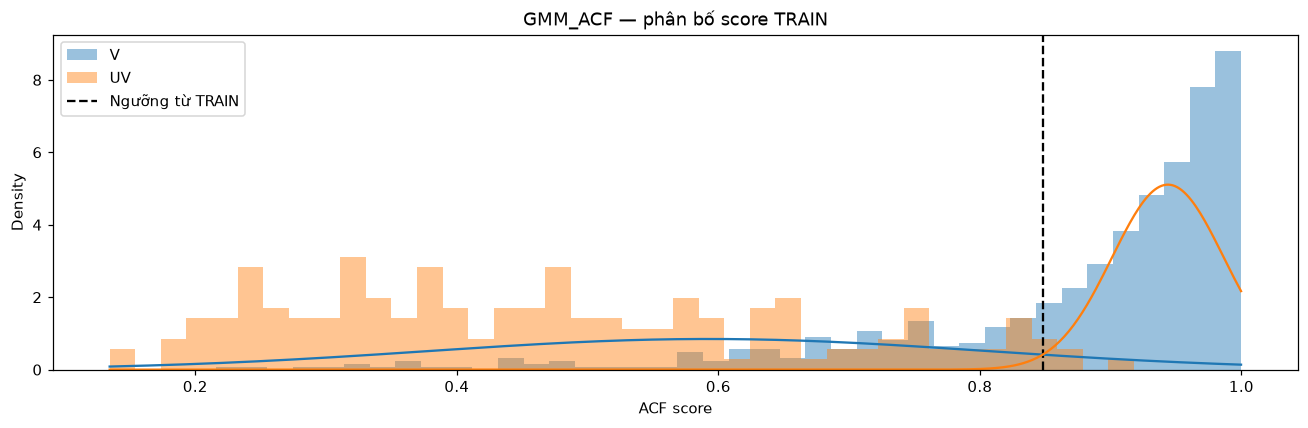

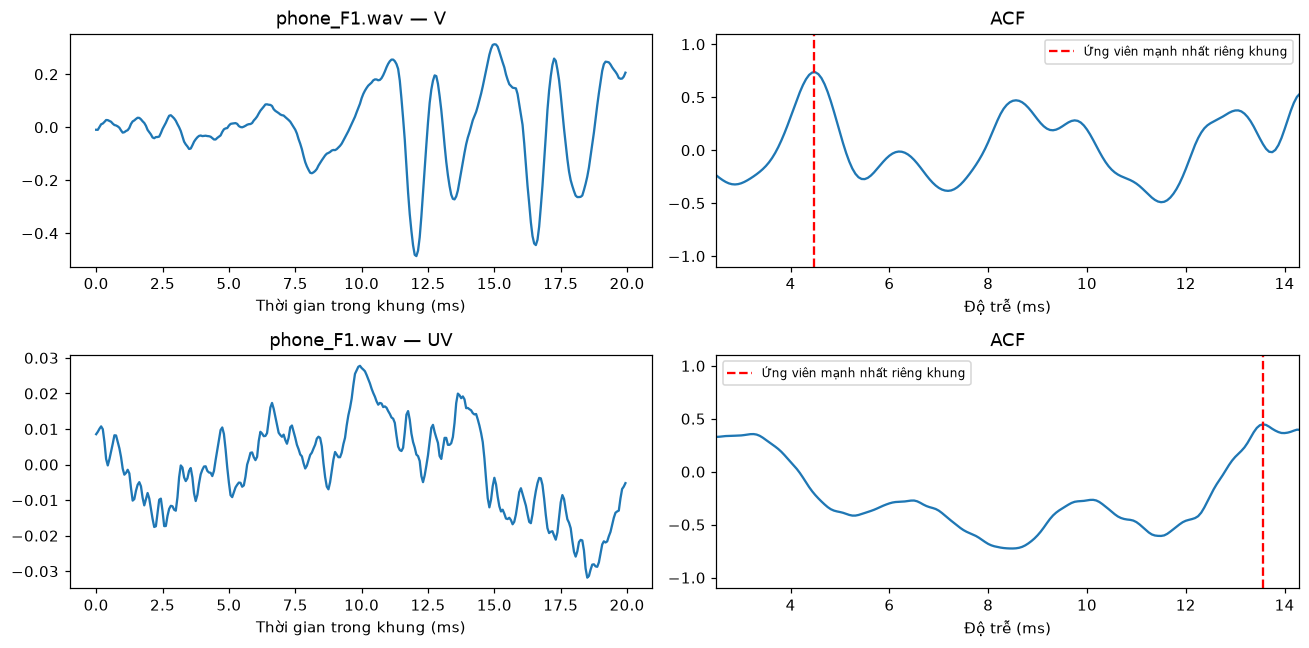

File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F1.wav,0.40,20.29,20.27,13.65
phone_M1.wav,0.55,9.63,27.16,12.44
studio_F1.wav,1.31,10.53,15.75,9.20
studio_M1.wav,5.06,7.62,9.76,7.48
TỔNG CỘNG,1.83,12.02,18.23,10.69


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F1.wav,214.7369,24.7790,118,0.8153,0.7582,0.9710,0.8646,0
phone_M1.wav,123.0253,18.4185,169,0.7208,0.6926,1.0000,0.8463,0
studio_F1.wav,226.5871,40.6754,107,0.7750,0.8130,0.9583,0.8857,6
studio_M1.wav,110.9834,24.3885,74,0.7100,0.7021,0.9200,0.8111,6


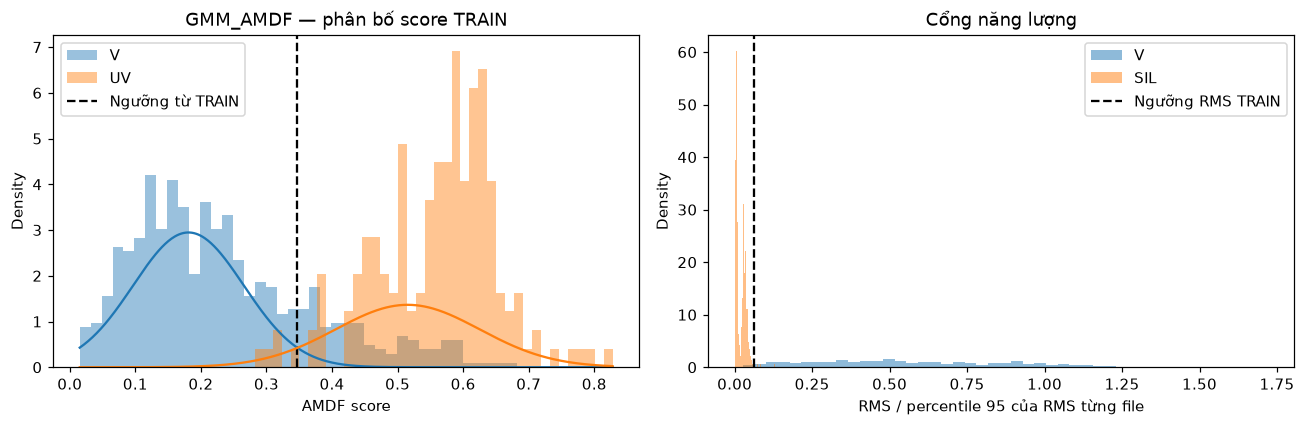

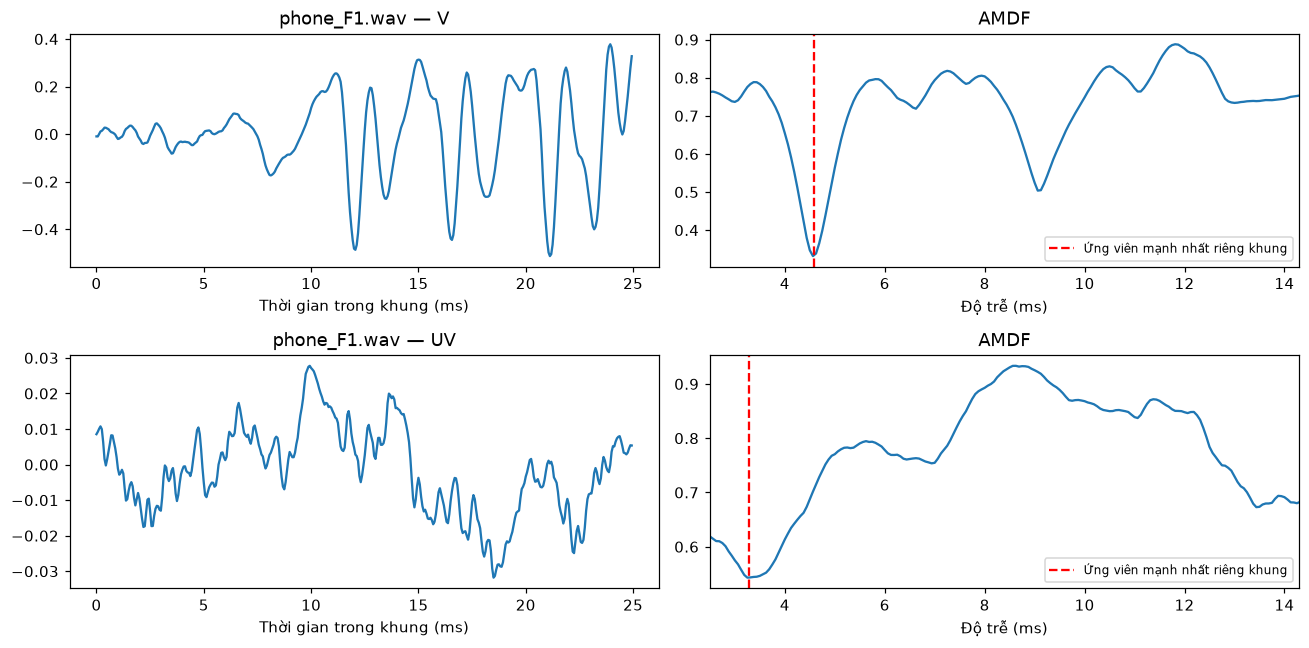

File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F1.wav,0.31,0.60,12.84,4.58
phone_M1.wav,0.80,13.13,18.97,10.97
studio_F1.wav,0.52,2.69,15.75,6.32
studio_M1.wav,2.81,11.92,13.41,9.38
TỔNG CỘNG,1.11,7.08,15.24,7.81


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F1.wav,216.2711,20.4769,129,0.8834,0.8431,1.0000,0.9216,0
phone_M1.wav,124.6957,19.0057,188,0.7639,0.7623,0.9677,0.8650,0
studio_F1.wav,230.7848,35.8107,107,0.8402,0.8699,1.0000,0.9350,0
studio_M1.wav,113.6179,23.2526,71,0.7728,0.7553,1.0000,0.8777,0


In [6]:
train_paths = sorted(TRAIN_DIR.glob('*.wav'))
assert len(train_paths) == 4, 'Bài yêu cầu đúng bốn file train'
train_by_frame = {}
for frame_ms in sorted({config['frame_ms'] for config in MODEL_CONFIGS.values()}):
    train_by_frame[frame_ms] = [attach_truth(signal_features(path, frame_ms), path.with_suffix('.lab'),
                                            TRAIN_STATS_DIR / path.with_suffix('.lab').name) for path in train_paths]
FITTED, TRAIN_ROWS, LOFO_ROWS = {}, {}, {}
for name, config in MODEL_CONFIGS.items():
    items = train_by_frame[config['frame_ms']]
    FITTED[name] = fit(items, config)
    print(name, '— cấu hình:', config, '— ngưỡng học từ TRAIN:', FITTED[name])
    threshold_plot(items, config, FITTED[name], name)
    curve_examples(items, config)
    TRAIN_ROWS[name] = evaluate(items, config, FITTED[name])
    show_results(TRAIN_ROWS[name], 'KẾT QUẢ TẬP TRAIN — ' + name)


## 6. Train cao/thấp chưa đủ: kiểm tra giữ riêng file
Train ở trên là chẩn đoán trên dữ liệu đã học ngưỡng. LOFO (leave one file out) giữ riêng một file,
học ngưỡng từ ba file còn lại rồi chấm file giữ riêng; lặp đủ bốn lần.
LOFO trong notebook giữ cố định cấu hình đã chọn, nên vẫn có thiên lệch do chọn cấu hình.
Nghiên cứu local đã làm **nested LOFO**: ba file vòng ngoài chọn cấu hình bằng LOFO vòng trong,
sau đó chấm file vòng ngoài chưa dùng để chọn. Bảng tham chiếu phía dưới là kết quả đó,
không phải phép kiểm tra nested đang chạy lại trong notebook này.
Các hướng thuật toán và tập cấu hình được xây dựng sau khi phân tích cả bốn file train;
nested LOFO kiểm tra việc chọn tham số trong tập cấu hình đó, chưa đánh giá độc lập toàn bộ quá trình nghiên cứu.
Chỉ có bốn file train nên validation vẫn biến động mạnh; cần thêm dữ liệu để khẳng định tổng quát.


In [7]:
validation_summary = []
for name, config in MODEL_CONFIGS.items():
    LOFO_ROWS[name] = lofo(train_by_frame[config['frame_ms']], config)
    show_results(LOFO_ROWS[name], 'VALIDATION GIỮ RIÊNG TỪNG FILE TRAIN — ' + name)
    ref = REFERENCE_TRAIN_VALIDATION[name]
    validation_summary.append({'Model': name, 'Train MAPE local (%)': ref['train']['average_mape'],
                               'LOFO MAPE local (%)': ref['lofo']['average_mape'],
                               'Nested LOFO MAPE local (%)': ref['nested_lofo']['average_mape'],
                               'Nested macro F1 V/UV': ref['nested_lofo']['macro_f1']})
display(pd.DataFrame(validation_summary).round(4))


VALIDATION GIỮ RIÊNG TỪNG FILE TRAIN — GMM_ACF
VALIDATION GIỮ RIÊNG TỪNG FILE TRAIN — GMM_AMDF


File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F1.wav,0.35,19.90,19.59,13.28
phone_M1.wav,0.06,9.30,40.52,16.62
studio_F1.wav,1.20,9.63,14.17,8.33
studio_M1.wav,6.07,6.46,6.10,6.21
TỔNG CỘNG,1.92,11.32,20.10,11.11


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F1.wav,214.8469,24.6999,119,0.8197,0.7647,0.9710,0.8679,0
phone_M1.wav,123.6256,18.3619,138,0.6308,0.5656,1.0000,0.7828,0
studio_F1.wav,226.8384,40.3423,109,0.7822,0.8211,0.9583,0.8897,7
studio_M1.wav,109.8069,24.6949,77,0.7058,0.7128,0.8800,0.7964,7


File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F1.wav,0.94,24.38,12.16,12.50
phone_M1.wav,1.03,13.72,20.69,11.81
studio_F1.wav,0.52,2.69,15.75,6.32
studio_M1.wav,2.81,11.92,13.41,9.38
TỔNG CỘNG,1.32,13.18,15.50,10.00


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F1.wav,217.6364,25.6230,130,0.8834,0.8431,1.0000,0.9216,1
phone_M1.wav,124.9698,19.1056,184,0.7513,0.7459,0.9677,0.8568,0
studio_F1.wav,230.7848,35.8107,107,0.8402,0.8699,1.0000,0.9350,0
studio_M1.wav,113.6179,23.2526,71,0.7728,0.7553,1.0000,0.8777,0


Model,Train MAPE local (%),LOFO MAPE local (%),Nested LOFO MAPE local (%),Nested macro F1 V/UV
GMM_ACF,10.6933,11.1122,13.2609,0.7346
GMM_AMDF,7.8119,10.0022,10.1016,0.8119


## 7. Áp dụng lên TEST độc lập với chọn cải tiến
Đọc WAV test và dự đoán **trước** khi đọc nhãn/thống kê test. Ngưỡng giữ nguyên từ train.
Sau đó mới đọc LAB để chấm và vẽ. Không fit GMM, không chọn ngưỡng, không sửa tham số bằng test.
Kết quả có thể kém bản cũ trên một số file test dù train và validation tốt hơn; vẫn báo cáo đúng.


KẾT QUẢ TẬP TEST — GMM_ACF
FINAL SCORE = 100 − 8.04 = 91.96%
Điểm thang 10 (1 chữ số thập phân): 9.2
KẾT QUẢ TẬP TEST — GMM_AMDF
FINAL SCORE = 100 − 6.50 = 93.50%
Điểm thang 10 (1 chữ số thập phân): 9.4


File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F2.wav,0.83,8.60,22.83,10.75
phone_M2.wav,0.34,0.21,19.51,6.69
studio_F2.wav,0.98,1.26,17.99,6.74
studio_M2.wav,3.31,6.83,13.79,7.98
TỔNG CỘNG,1.36,4.23,18.53,8.04


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F2.wav,151.4470,33.3391,169,0.7234,0.7021,0.9403,0.8212,0
phone_M2.wav,130.6377,15.3681,99,0.8036,0.7239,0.9846,0.8542,1
studio_F2.wav,196.6578,47.1956,114,0.7690,0.8248,0.9565,0.8907,0
studio_M2.wav,149.5872,32.3709,100,0.7136,0.7734,0.9500,0.8617,0


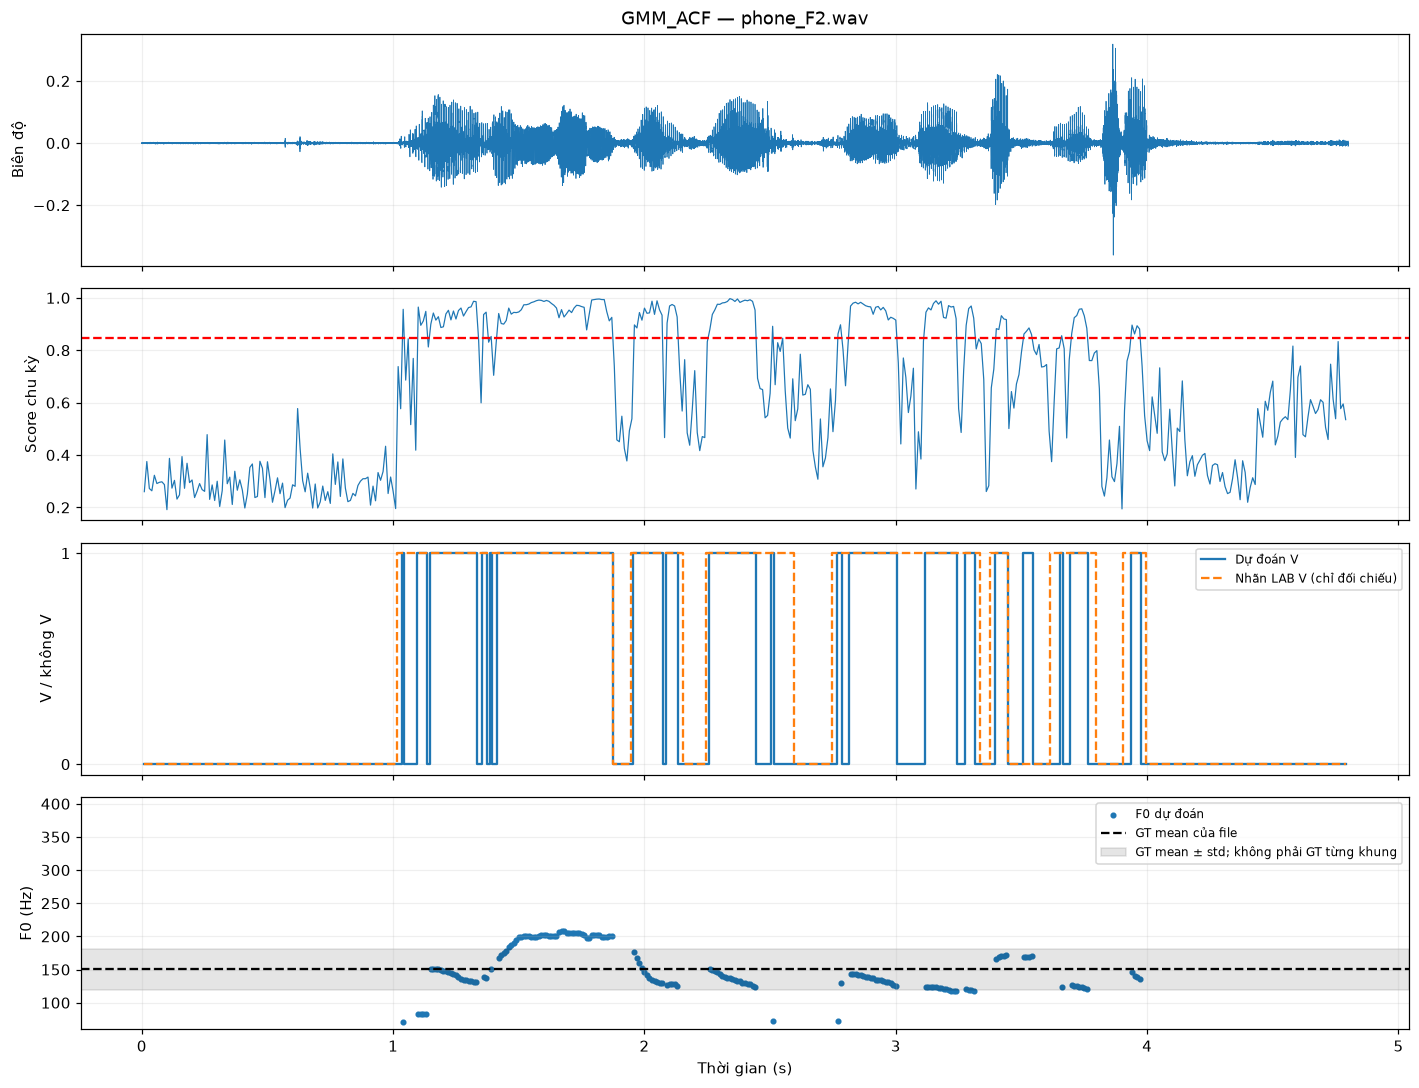

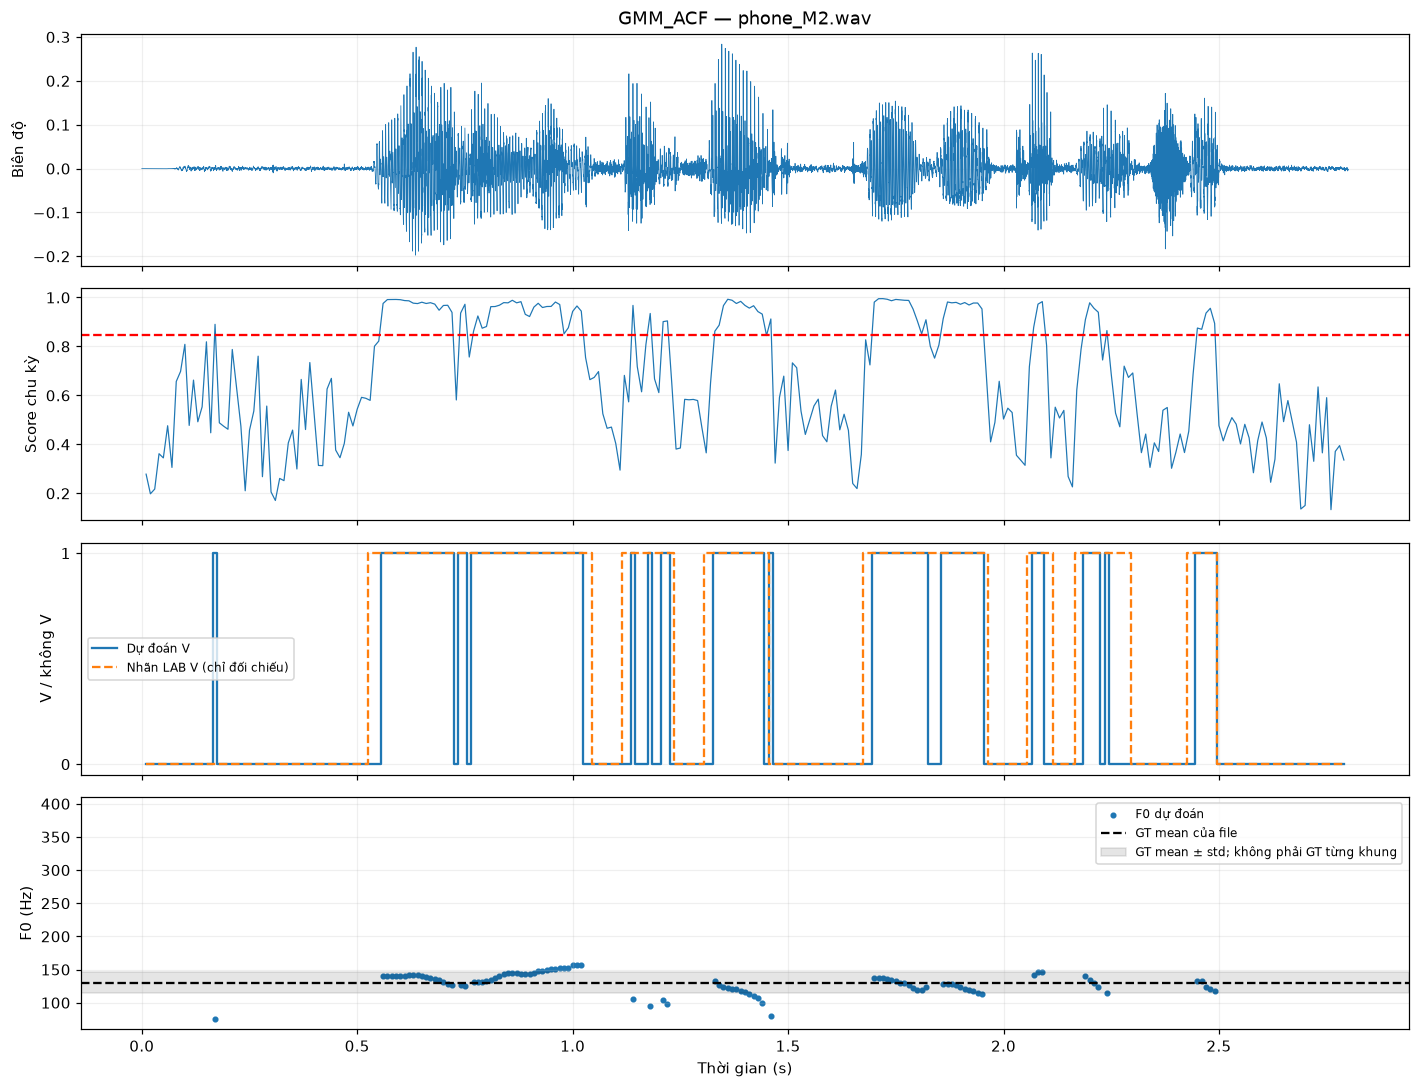

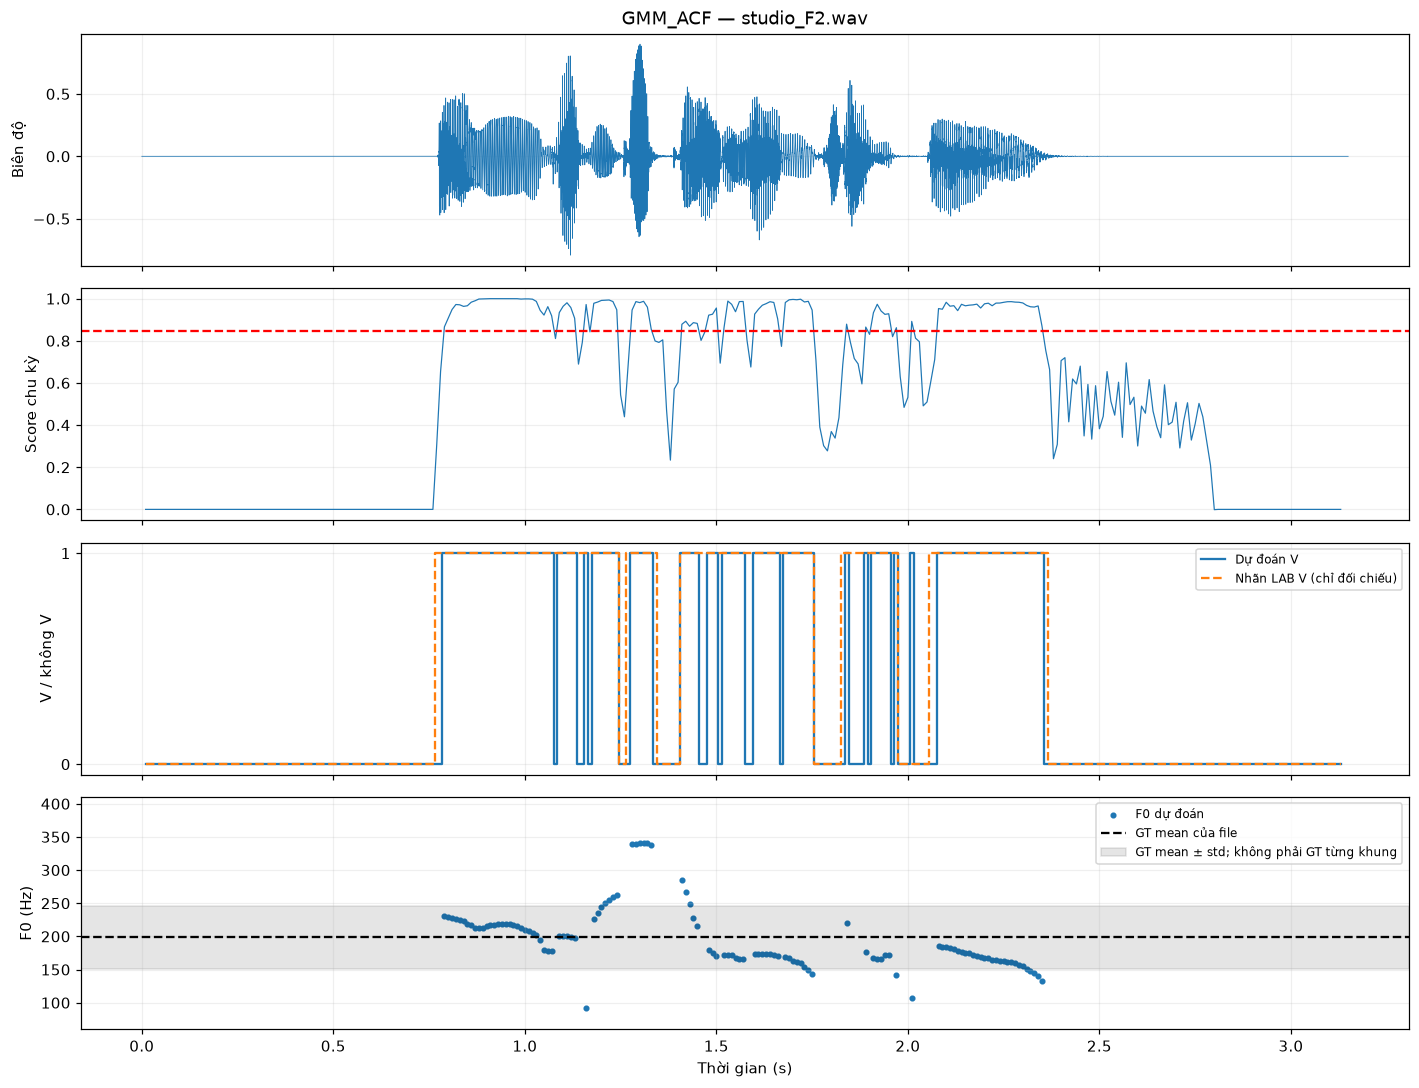

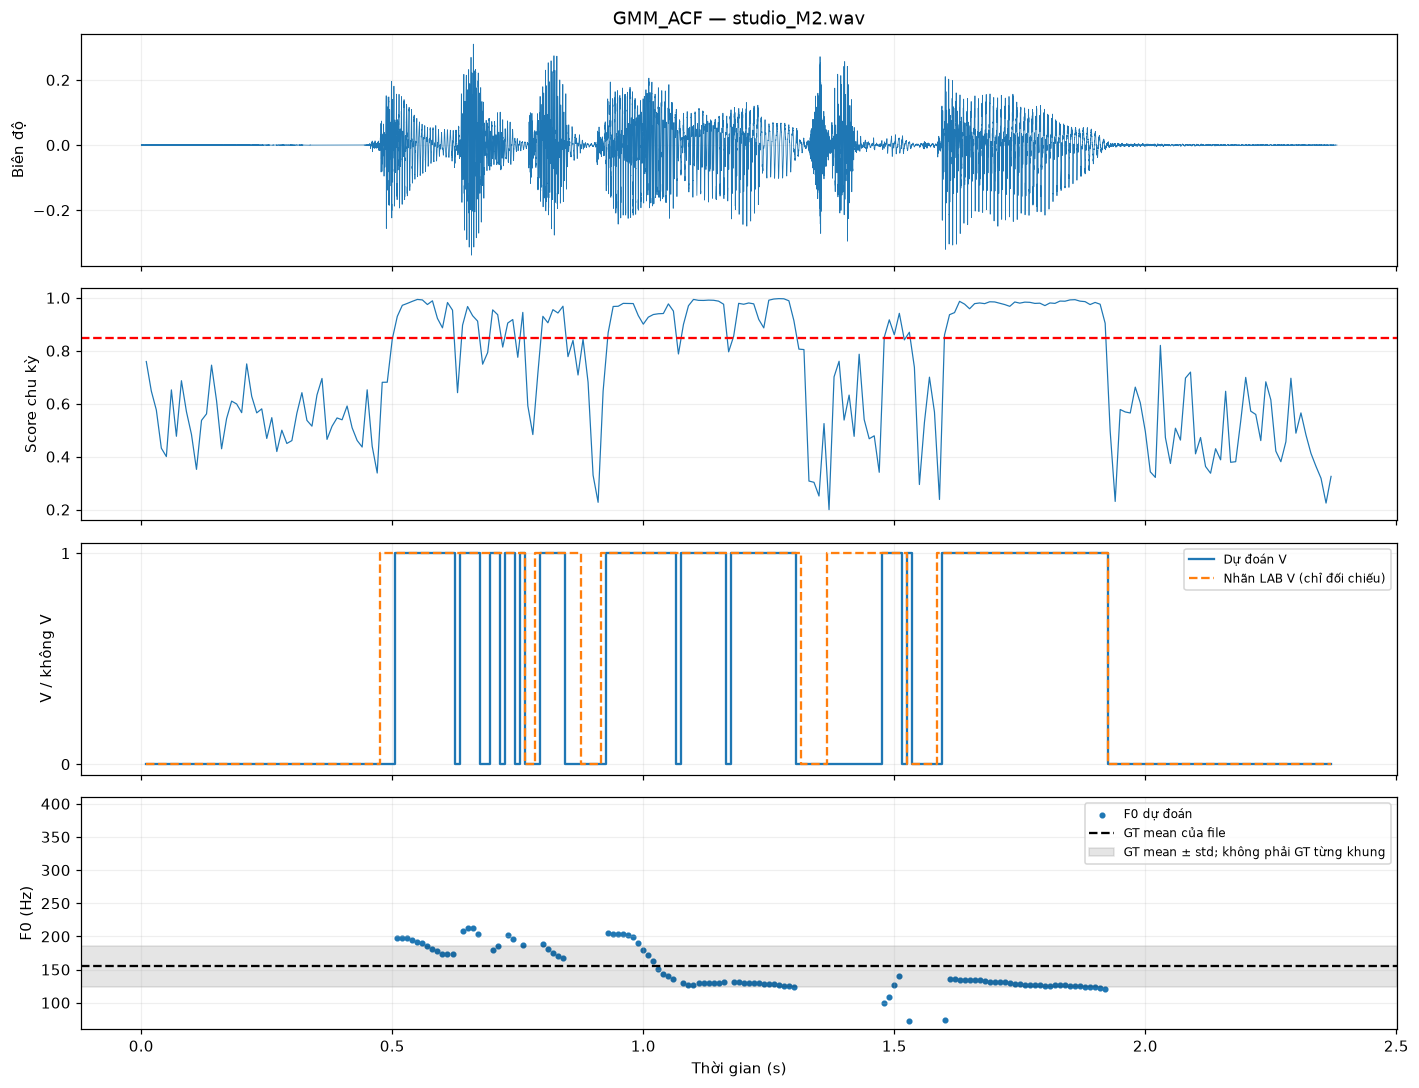

File,MAPE F0mean (%),MAPE F0std (%),MAPE F0num (%),Average MAPE (%)
phone_F2.wav,0.29,9.03,13.70,7.67
phone_M2.wav,0.07,1.08,17.89,6.34
studio_F2.wav,0.60,8.47,12.95,7.34
studio_M2.wav,1.04,1.64,11.21,4.63
TỔNG CỘNG,0.50,5.06,13.94,6.50


file,F0mean,F0std,F0num,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil
phone_F2.wav,149.7673,33.4737,189,0.7436,0.7617,0.8657,0.8137,1
phone_M2.wav,130.2849,15.2344,101,0.8182,0.7463,0.9846,0.8654,0
studio_F2.wav,197.4063,43.7498,121,0.8400,0.8832,1.0000,0.9416,0
studio_M2.wav,153.0960,29.8027,103,0.7536,0.8047,1.0000,0.9023,0


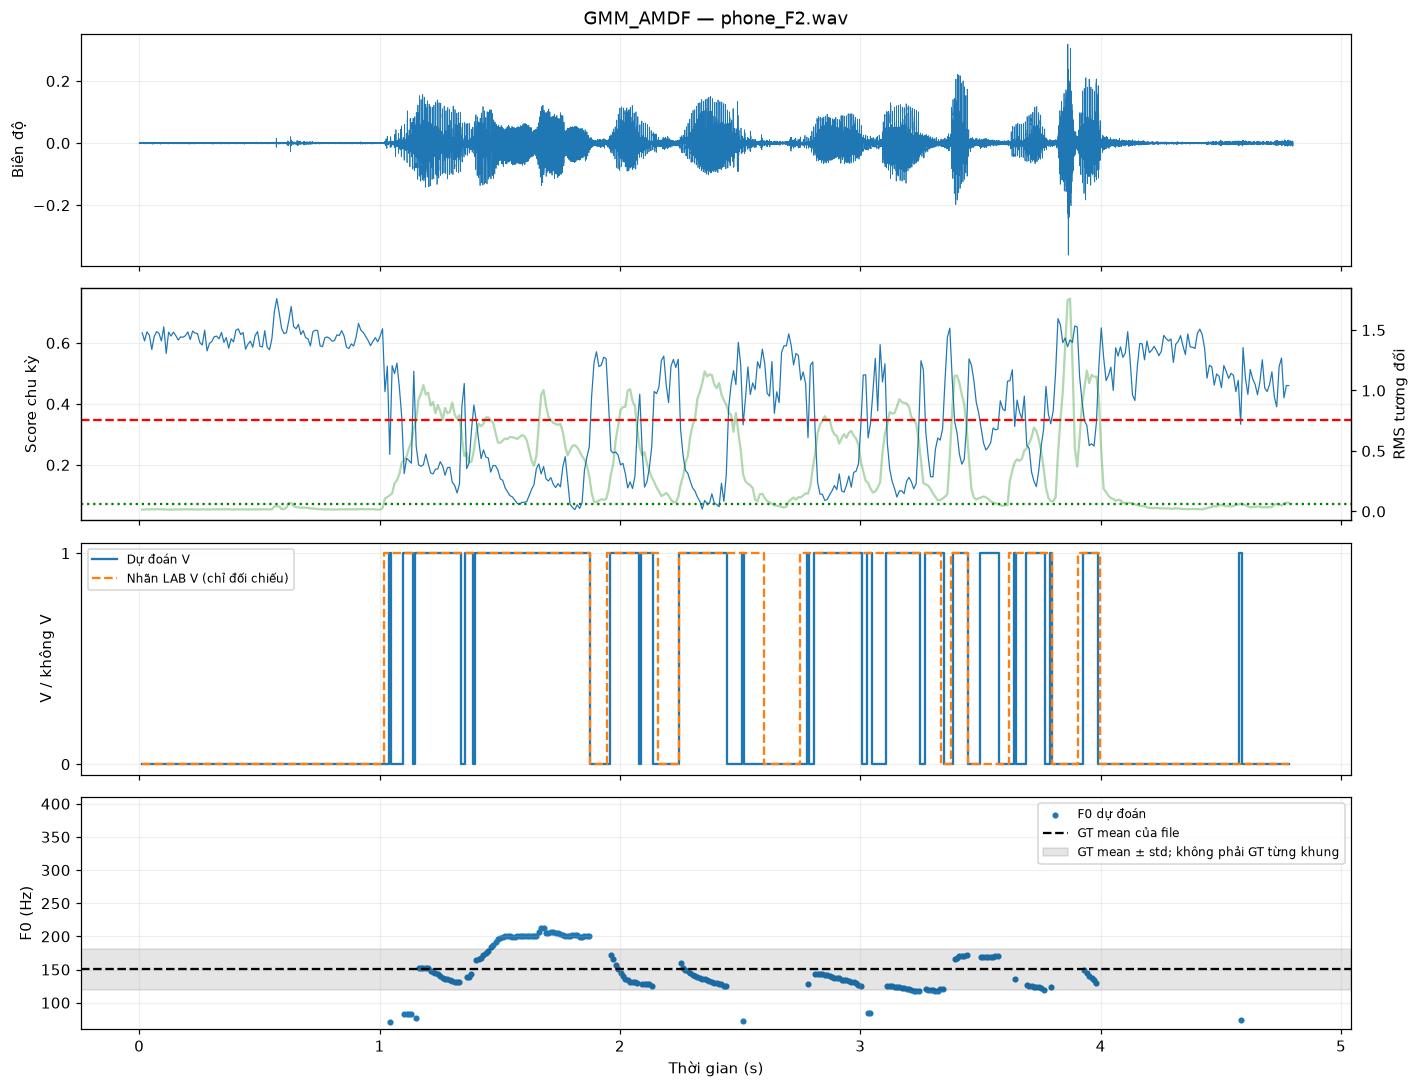

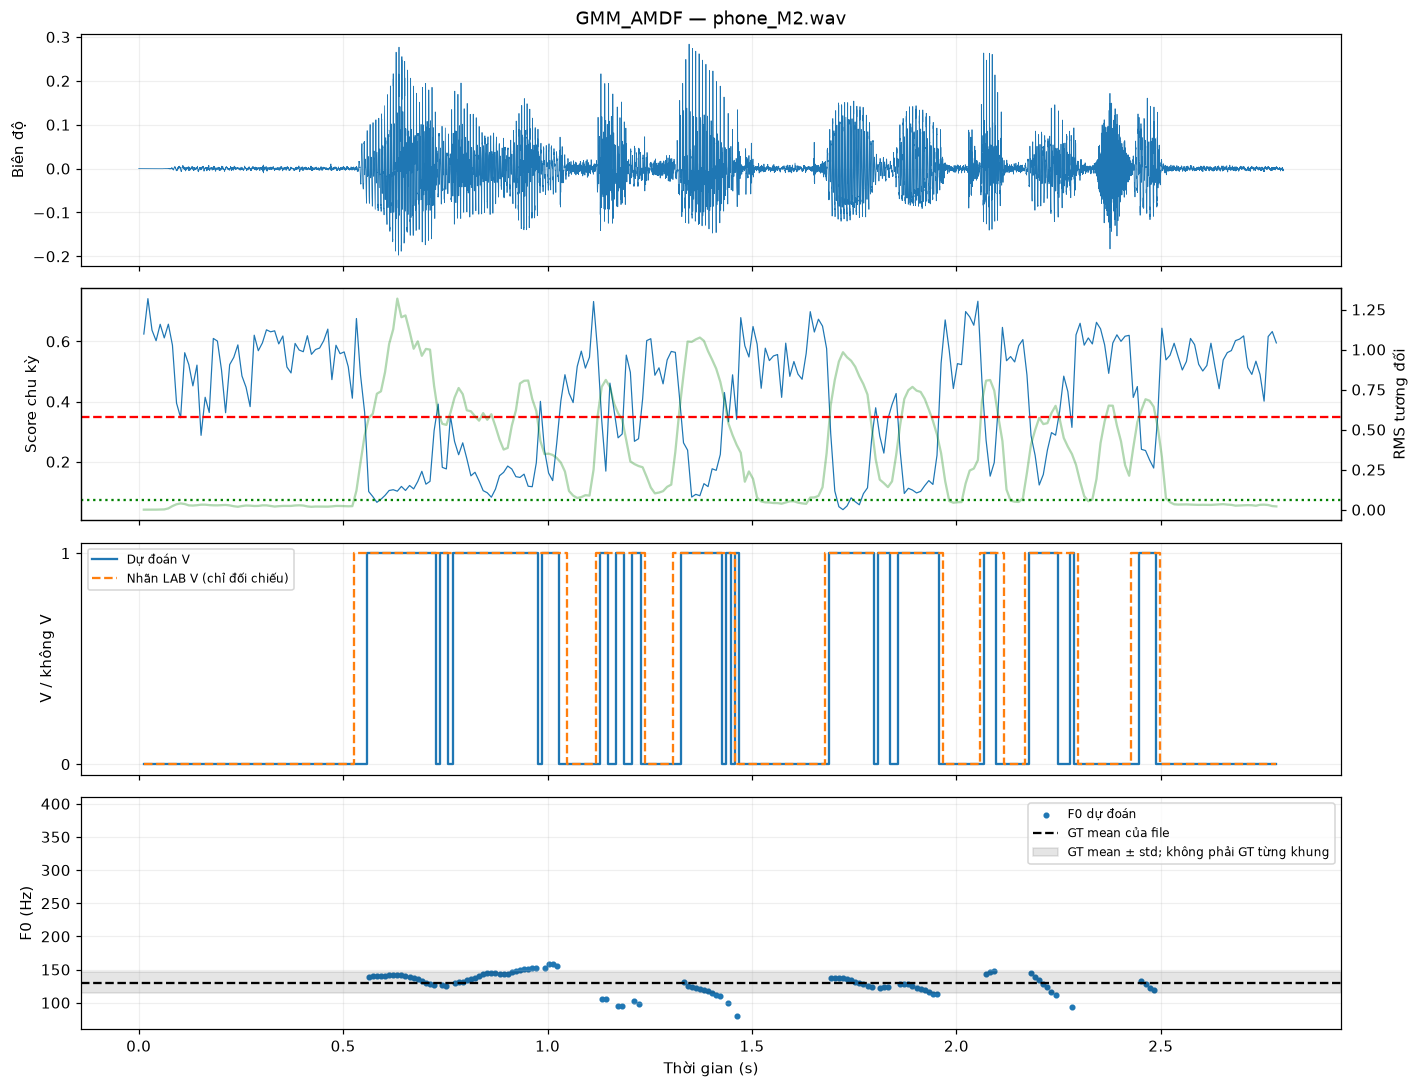

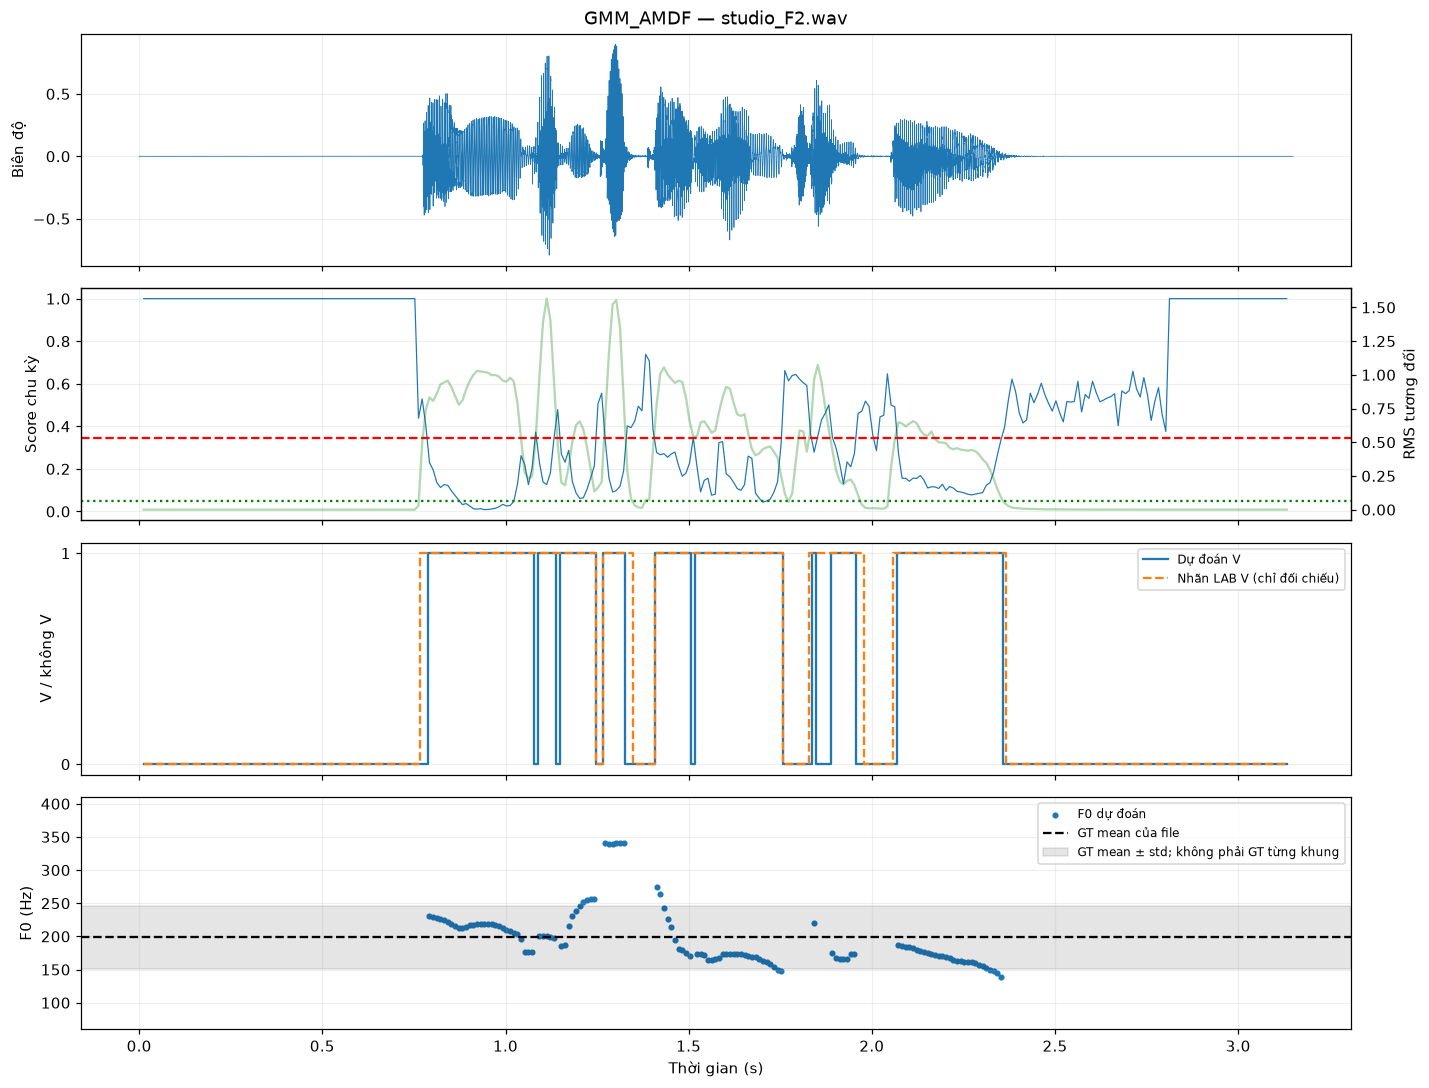

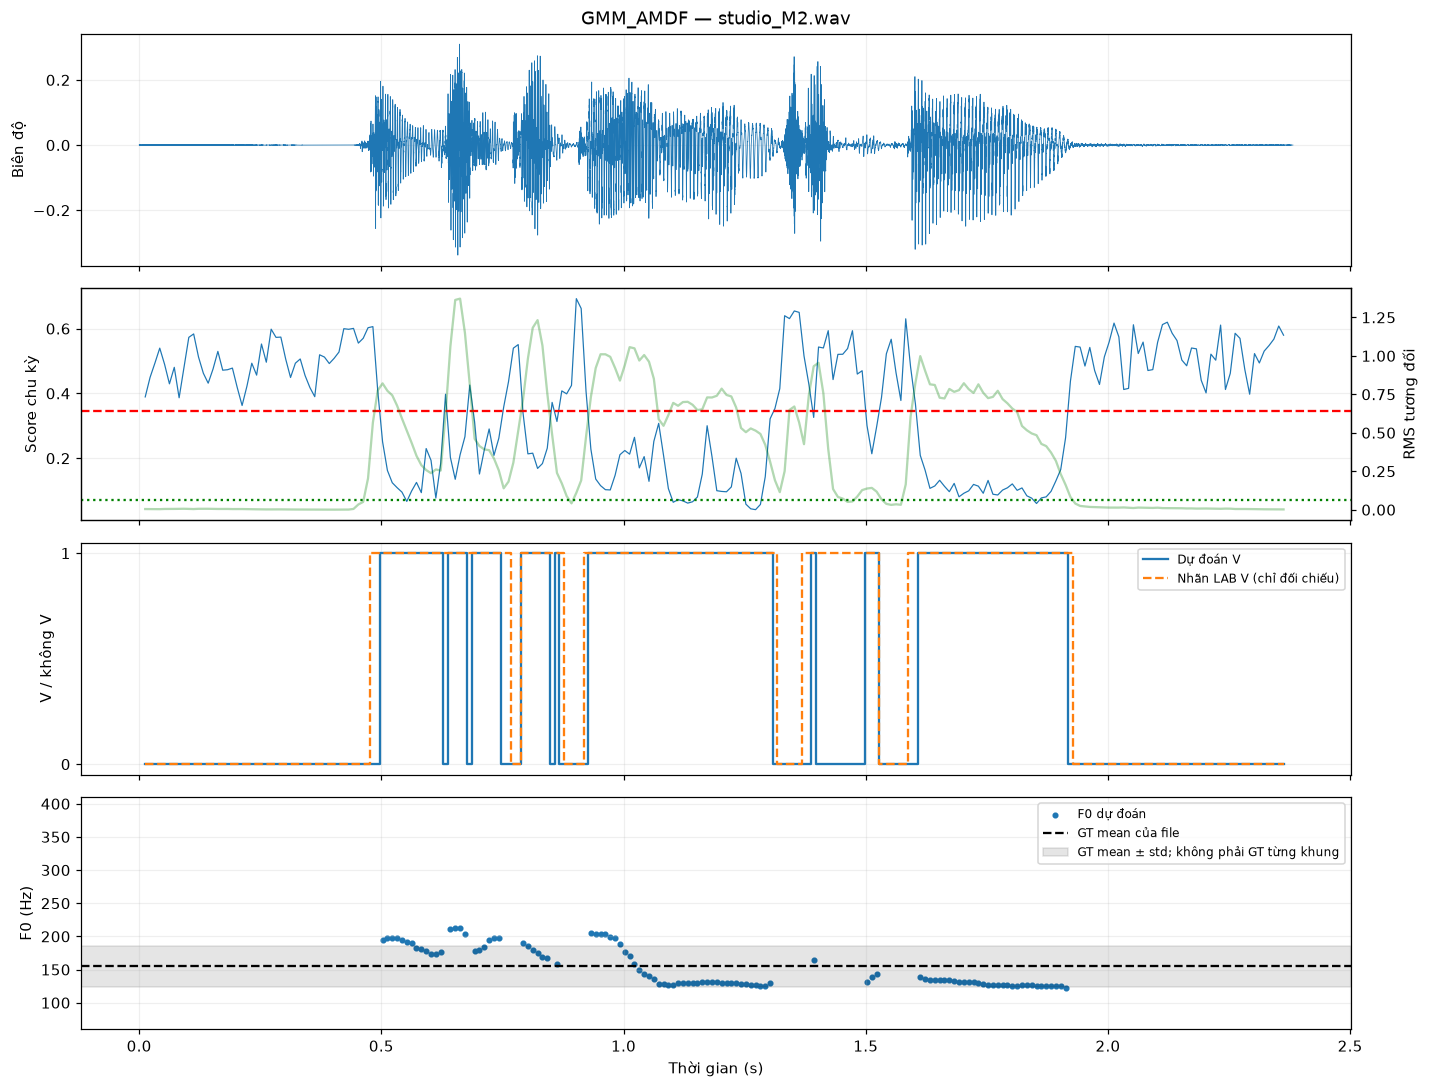

In [8]:
assert TEST_DIR.exists() and TEST_STATS_DIR.exists(), 'Thiếu thư mục test hoặc test-3groundtruth'
test_paths = sorted(TEST_DIR.glob('*.wav'))
assert len(test_paths) == 4, 'Bài yêu cầu đúng bốn file test'
test_by_frame = {frame_ms: [signal_features(path, frame_ms) for path in test_paths]
                 for frame_ms in sorted({config['frame_ms'] for config in MODEL_CONFIGS.values()})}
TEST_ROWS, TEST_PREDICTIONS, TEST_LABELED = {}, {}, {}
for name, config in MODEL_CONFIGS.items():
    predictions = [infer(item, config, FITTED[name]) for item in test_by_frame[config['frame_ms']]]
    # Nhãn và thống kê test chỉ được gắn sau khi đã dự đoán xong.
    items = [attach_truth(item, TEST_DIR / Path(item['file']).with_suffix('.lab'),
                          TEST_STATS_DIR / Path(item['file']).with_suffix('.lab'))
             for item in test_by_frame[config['frame_ms']]]
    TEST_ROWS[name] = pd.DataFrame([score_file(item, *prediction) for item, prediction in zip(items, predictions)])
    TEST_PREDICTIONS[name], TEST_LABELED[name] = predictions, items
    show_results(TEST_ROWS[name], 'KẾT QUẢ TẬP TEST — ' + name)
    average_mape = float(TEST_ROWS[name].average_mape.mean())
    final_score = 100 - average_mape
    print(f'FINAL SCORE = 100 − {average_mape:.2f} = {final_score:.2f}%')
    print(f'Điểm thang 10 (1 chữ số thập phân): {final_score / 10:.1f}')
    if SHOW_DETAILED_TEST_PLOTS:
        for item in items:
            detailed_plot(item, config, FITTED[name], TEST_DIR / item['file'], name)


## 8. Đọc kết quả và điền bảng của thầy
Lấy bảng **KẾT QUẢ TẬP TRAIN** và **KẾT QUẢ TẬP TEST**, gồm bốn dòng file và dòng TỔNG CỘNG.
Notebook GMM in riêng hai thuật toán ACF và AMDF để so sánh.
Macro F1/recall V/recall UV chỉ chấm khung có nhãn V/UV; lỗi nhận SIL là V được báo riêng.
Các đường GT mean ± std trên đồ thị là thống kê của file, không phải đường F0 chuẩn theo thời gian.

Muốn giữ test độc lập, không đổi cấu hình theo bảng test rồi dùng lại test để tuyên bố cải thiện.

Tham khảo: [Praat: chọn phương pháp pitch](https://www.fon.hum.uva.nl/praat/manual/how_to_choose_a_pitch_analysis_method.html),
[Praat: các ứng viên và chi phí chọn đường](https://www.fon.hum.uva.nl/praat/manual/pitch_analysis_by_filtered_autocorrelation.html).
